# Consumer Purchase Intention in E-Commerce: The Role of Online Reviews

## A Quantitative Survey-Based Analysis

**Module:** BUSI 1783 – Business Analytics Project
**Programme:** MSc Business Analytics, University of Greenwich
**Student:** Vishwakumari Patel (001486172)
**Supervisor:** Dr Azar MahmoumGonbadi
**Project type:** Traditional Research Project

---

### About this analysis

This notebook analyses primary survey data collected on consumer perceptions of online product
reviews and their reported purchase intention in e-commerce settings. The questionnaire captured
three multi-item attitudinal constructs measured on five-point Likert scales, together with a
single-item measure of review-driven purchase intention and a set of behavioural and demographic
variables.

The analytical strategy is entirely quantitative and proceeds as follows:

1. Data cleaning and preparation (consent screening, duplicate removal, recoding, missing values,
   careless-responding checks)
2. Descriptive statistics and sample profiling
3. Reliability analysis of the multi-item constructs (Cronbach's alpha)
4. Construction and distributional testing of composite scores
5. Correlation analysis (Pearson and Spearman)
6. Simple linear regression
7. Hierarchical multiple linear regression with purchase intention as the dependent variable
8. Full testing of the classical linear regression assumptions
9. Robustness and sensitivity analyses (ordinal logistic regression; careless-responder exclusion)
10. Supplementary non-parametric group comparisons
11. Post-hoc statistical power assessment

In [1]:
# Install any packages that are not already available in the environment
# (statsmodels is required for regression modelling and diagnostic testing)
!pip install statsmodels --quiet

In [2]:
# Import the necessary libraries
import pandas as pd                                   # pandas is used for dataframing
import numpy as np                                    # numpy is used for numeric data
import matplotlib.pyplot as plt                       # matplotlib is for data visualisation
import seaborn as sns                                 # advanced version for data visualisation eg: heatmap
import statsmodels.api as sm                          # for statistical tests
import statsmodels.formula.api as smf                 # formula interface for regression models
from statsmodels.formula.api import ols               # for ols model - ordinary least squares
from statsmodels.miscmodels.ordinal_model import OrderedModel   # ordinal logistic regression
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson # Durbin-Watson test for autocorrelation in residuals
from statsmodels.stats.power import FTestAnovaPower
import scipy.stats as stats                           # correlation, hypothesis testing and regression support
from scipy.stats import pearsonr, spearmanr           # for correlation and hypothesis analysis
import warnings
warnings.filterwarnings('ignore')

# Global display and plotting settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300          # 300 dpi as required for the poster and report figures
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Create a folder to store all figures at publication quality so they can be inserted
# directly into the dissertation and the A0 poster
import os
os.makedirs('figures', exist_ok=True)

def save_fig(name):
    """Save the current matplotlib figure into the figures folder at 300 dpi."""
    plt.savefig(f'figures/{name}.png')

print("Figure directory ready.")

Figure directory ready.


---
## 1. Importing the Dataset

The dataset consists of responses collected through an online questionnaire distributed to
e-commerce consumers. Each row represents one respondent and each column represents one
questionnaire item.

In [4]:
# Import the dataset
# NOTE: update the file path below to the location of the file on your own machine
df = pd.read_excel('Intention in E-Commerce_ The Role of Online Reviews (Responses).xlsx')

print(f"Raw dataset dimensions: {df.shape[0]} responses x {df.shape[1]} variables")
df.head()

Raw dataset dimensions: 57 responses x 29 variables


,Timestamp,Do you consent to participate in this research study?,What is your age?,Gender,Employment Status ?,Country of Residence,How often do you shop online?,Which online shopping platform do you use most?,Approximately how much do you spend on online shopping each month?,Which product categories do you purchase online? (Select all that apply.),How often do you read customer reviews before purchasing a product?,Approximately how many reviews do you usually read?,Which review feature do you consider most important?,Please indicate your level of agreement. [Detailed reviews are more trustworthy than short reviews.],Please indicate your level of agreement. [Reviews with customer sharing product photos increase my confidence.],Please indicate your level of agreement. [Reviews discussing both advantages and disadvantages seem more genuine.],Please indicate your level of agreement. [Recent reviews are more useful than older reviews.],"Please indicate your level of agreement with the following statements about Verified Purchase reviews. [I trust reviews marked as ""Verified Purchase.""]",Please indicate your level of agreement with the following statements about Verified Purchase reviews. [I am more likely to purchase products with many verified reviews.],Please indicate your level of agreement with the following statements about Verified Purchase reviews. [Reviews without a Verified Purchase badge are less trustworthy.],Please indicate your level of agreement with the following statements regarding your purchase decisions. [Positive customer reviews increase my likelihood of purchasing a product.],Please indicate your level of agreement with the following statements regarding your purchase decisions. [Negative reviews discourage me from purchasing a product.],Please indicate your level of agreement with the following statements regarding your purchase decisions. [High star ratings influence my purchase decisions.],Please indicate your level of agreement with the following statements regarding your purchase decisions. [I often purchase products after reading positive customer reviews.],Have you ever returned a product because it did not match its reviews?,Have you ever bought a product without reading reviews?,"After reading customer reviews, how likely are you to purchase the product?",What makes an online product review trustworthy?,Describe a purchase where customer reviews significantly influenced your decision.
0,2026-07-28 02:29:23.720,I agree to participate in this research study.,18–24,Female,Part-time employed,United Kingdom,Monthly,SHEIN,Less than £50,"Fashion & Clothing, Beauty & Skincare, Health ...",Often,4–6,Customer Photos,Neutral,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Agree,Neutral,Strongly Agree,Strongly Agree,Agree,Agree,No,Rarely,Very Unlikely,NaN,NaN
1,2026-07-28 02:38:34.187,I agree to participate in this research study.,18–24,Male,Student,London,More than once a week,Amazon,Less than £50,"Fashion & Clothing, Beauty & Skincare, Electro...",Always,1–3,Star Rating,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Disagree,Neutral,Agree,Strongly Disagree,Neutral,Disagree,Strongly Agree,Yes,Frequently,Neutral,Honesty and transparency,When i suggested something and they found my c...
2,2026-07-28 02:46:07.492,I agree to participate in this research study.,25–34,Female,Full-time employed,india,Weekly,ikea,£251–£500,"Fashion & Clothing, Beauty & Skincare, Home & ...",Rarely,1–3,Helpful Votes,Neutral,Agree,Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Neutral,Yes,Rarely,Likely,their pictures and short reviews,"i trust on product ,brand more then reviews"
3,2026-07-28 04:04:52.348,I agree to participate in this research study.,18–24,Male,Student,India,Every few months,Amazon,£50–£100,"Fashion & Clothing, Electronics, Books",Always,1–3,Verified Purchase Badge,Neutral,Neutral,Agree,Disagree,Disagree,Disagree,Disagree,Agree,Disagree,Disagree,D

In [5]:
# Visualise dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 29 columns):
 #   Column                                                                                                                                                                                Non-Null Count  Dtype         
---  ------                                                                                                                                                                                --------------  -----         
 0   Timestamp                                                                                                                                                                             57 non-null     datetime64[us]
 1   Do you consent to participate in this research study?                                                                                                                                 57 non-null     str           
 2   What is your age?              

In [6]:
# Display the full wording of every questionnaire item so that variable coding is transparent
for i, col in enumerate(df.columns):
    print(f"[{i:2d}] {col}")

[ 0] Timestamp
[ 1] Do you consent to participate in this research study?
[ 2] What is your age?
[ 3] Gender
[ 4] Employment Status ?
[ 5] Country of Residence
[ 6] How often do you shop online?
[ 7] Which online shopping platform do you use most?
[ 8] Approximately how much do you spend on online shopping each month?
[ 9] Which product categories do you purchase online? (Select all that apply.)
[10] How often do you read customer reviews before purchasing a product?
[11] Approximately how many reviews do you usually read?
[12] Which review feature do you consider most important?
[13] Please indicate your level of agreement. [Detailed reviews are more trustworthy than short reviews.]
[14] Please indicate your level of agreement. [Reviews with customer sharing product  photos increase my confidence.]
[15] Please indicate your level of agreement. [Reviews discussing both advantages and disadvantages seem more genuine.]
[16] Please indicate your level of agreement. [Recent reviews are mor

---
## 2. Data Cleaning and Preparation

Survey data collected through an online form requires systematic cleaning before it can be
analysed. The following steps are performed in sequence, and each is documented so that the
process is fully reproducible:

| Step | Purpose |
|---|---|
| 2.1 | Rename items to short analytical variable codes |
| 2.2 | Verify informed consent |
| 2.3 | Identify and remove duplicate submissions |
| 2.4 | Standardise free-text categorical entries |
| 2.5 | Recode ordinal and Likert responses to numeric scales |
| 2.6 | Assess and treat missing values |
| 2.7 | Screen for careless / insufficient-effort responding |
| 2.8 | Export the cleaned analytical dataset |

### 2.1 Renaming variables to analytical codes

The original column headings are the full questionnaire wording, which is unwieldy in code.
Each item is therefore mapped to a short code. The three multi-item constructs are coded as:

* **RQ1–RQ4** — Perceived Review Quality / Credibility
* **VPT1–VPT3** — Trust in Verified-Purchase Reviews
* **RIN1–RIN4** — Perceived Review Influence on Purchase Behaviour
* **PI** — Purchase Intention (dependent variable)

Assignment of items to constructs is theory-driven rather than based on the order in which the
items happened to appear in the questionnaire (see Chapter 2 of the dissertation for the
supporting literature).

In [7]:
# Work on a copy so that the raw import is preserved for audit purposes
df = df.copy()

# Map the full questionnaire wording onto short analytical variable names
rename_map = {
    df.columns[0]:  'timestamp',
    df.columns[1]:  'consent',
    df.columns[2]:  'age',
    df.columns[3]:  'gender',
    df.columns[4]:  'employment',
    df.columns[5]:  'country',
    df.columns[6]:  'shop_freq',
    df.columns[7]:  'platform',
    df.columns[8]:  'monthly_spend',
    df.columns[9]:  'categories',
    df.columns[10]: 'review_read_freq',
    df.columns[11]: 'reviews_read_n',
    df.columns[12]: 'key_review_feature',
    # --- Construct 1: Perceived Review Quality / Credibility ---
    df.columns[13]: 'RQ1',   # Detailed reviews are more trustworthy than short reviews
    df.columns[14]: 'RQ2',   # Reviews with customer photos increase my confidence
    df.columns[15]: 'RQ3',   # Reviews discussing both advantages and disadvantages seem more genuine
    df.columns[16]: 'RQ4',   # Recent reviews are more useful than older reviews
    # --- Construct 2: Trust in Verified-Purchase Reviews ---
    df.columns[17]: 'VPT1',  # I trust reviews marked as "Verified Purchase"
    df.columns[18]: 'VPT2',  # I am more likely to purchase products with many verified reviews
    df.columns[19]: 'VPT3',  # Reviews without a Verified Purchase badge are less trustworthy
    # --- Construct 3: Perceived Review Influence on Purchase Behaviour ---
    df.columns[20]: 'RIN1',  # Positive customer reviews increase my likelihood of purchasing
    df.columns[21]: 'RIN2',  # Negative reviews discourage me from purchasing a product
    df.columns[22]: 'RIN3',  # High star ratings influence my purchase decisions
    df.columns[23]: 'RIN4',  # I often purchase products after reading positive customer reviews
    # --- Behavioural items and dependent variable ---
    df.columns[24]: 'returned_product',
    df.columns[25]: 'bought_without_reviews',
    df.columns[26]: 'PI',    # DEPENDENT VARIABLE: likelihood of purchasing after reading reviews
    df.columns[27]: 'open_trust',
    df.columns[28]: 'open_experience',
}
df = df.rename(columns=rename_map)

# Store a lookup of code -> original item wording for the appendix of the dissertation
item_wording = pd.DataFrame({'code': list(rename_map.values()),
                             'questionnaire_item': list(rename_map.keys())})

likert_items = ['RQ1', 'RQ2', 'RQ3', 'RQ4', 'VPT1', 'VPT2', 'VPT3', 'RIN1', 'RIN2', 'RIN3', 'RIN4']
constructs = {'RQ':  ['RQ1', 'RQ2', 'RQ3', 'RQ4'],
              'VPT': ['VPT1', 'VPT2', 'VPT3'],
              'RIN': ['RIN1', 'RIN2', 'RIN3', 'RIN4']}

print("Variables renamed. Analytical codes:")
print(list(df.columns))

Variables renamed. Analytical codes:
['timestamp', 'consent', 'age', 'gender', 'employment', 'country', 'shop_freq', 'platform', 'monthly_spend', 'categories', 'review_read_freq', 'reviews_read_n', 'key_review_feature', 'RQ1', 'RQ2', 'RQ3', 'RQ4', 'VPT1', 'VPT2', 'VPT3', 'RIN1', 'RIN2', 'RIN3', 'RIN4', 'returned_product', 'bought_without_reviews', 'PI', 'open_trust', 'open_experience']


### 2.2 Verifying informed consent

Ethical approval for this study required that only responses accompanied by explicit informed
consent are analysed. Any response without recorded consent is removed.

In [8]:
print("Consent responses:")
print(df['consent'].value_counts(dropna=False))

n_before = len(df)
df = df[df['consent'].str.contains('agree', case=False, na=False)].copy()
print(f"\nResponses removed for missing consent: {n_before - len(df)}")
print(f"Responses retained: {len(df)}")

Consent responses:
consent
I agree to participate in this research study.    57
Name: count, dtype: int64

Responses removed for missing consent: 0
Responses retained: 57


### 2.3 Removing duplicate submissions

Online questionnaires can capture the same response twice, for example where a respondent
resubmits the form or refreshes the confirmation page. Duplicates are identified by comparing
every substantive answer (all variables except the automatically generated timestamp). Retaining
duplicates would artificially inflate the sample size and distort the estimated standard errors.

In [9]:
# Identify duplicate submissions on all substantive answers, ignoring the timestamp
substantive = [c for c in df.columns if c != 'timestamp']
dupe_mask = df.duplicated(subset=substantive, keep=False)

print(f"Rows involved in duplicate pairs: {dupe_mask.sum()}")
if dupe_mask.sum() > 0:
    display(df.loc[dupe_mask, ['age', 'gender', 'country', 'platform', 'PI']])

n_before = len(df)
df = df.drop_duplicates(subset=substantive, keep='first').reset_index(drop=True)
print(f"\nDuplicate responses removed: {n_before - len(df)}")
print(f"Analytical sample after de-duplication: n = {len(df)}")

Rows involved in duplicate pairs: 4


,age,gender,country,platform,PI
9,25–34,Male,India,Amazon,Very Likely
10,25–34,Male,India,Amazon,Very Likely
26,18–24,Male,India,Amazon,Neutral
27,18–24,Male,India,Amazon,Neutral



Duplicate responses removed: 2
Analytical sample after de-duplication: n = 55


### 2.4 Standardising free-text categorical entries

Two questions accepted free-text input (country of residence and shopping platform), producing
inconsistent spellings, trailing whitespace and city-level answers where a country was requested.
These are standardised so that frequency tables are meaningful.

In [10]:
print("Country of residence BEFORE cleaning:")
print(df['country'].value_counts(dropna=False))

Country of residence BEFORE cleaning:
country
India              28
India              11
United Kingdom      4
Indian              2
Canada              2
United Kingdom      2
London              1
india               1
Mumbai              1
India-396580        1
UK                  1
London              1
Name: count, dtype: int64


In [11]:
# Strip whitespace and apply consistent title casing across all text columns
text_cols = df.select_dtypes(include='object').columns
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})

# Standardise country of residence: map spelling variants and city-level answers to countries
country_map = {
    'india': 'India', 'indian': 'India', 'mumbai': 'India', 'india-396580': 'India',
    'united kingdom': 'United Kingdom', 'uk': 'United Kingdom', 'london': 'United Kingdom',
    'england': 'United Kingdom', 'canada': 'Canada',
}
df['country'] = df['country'].str.lower().map(country_map).fillna(df['country'])

# Standardise platform names
platform_map = {'ikea': 'IKEA', 'zara': 'Zara', 'zara h&m': 'Other', 'savana': 'Other',
                'temu': 'Temu', 'flipkart': 'Flipkart', 'shein': 'SHEIN', 'amazon': 'Amazon'}
df['platform'] = df['platform'].str.lower().map(platform_map).fillna('Other')

print("Country of residence AFTER cleaning:")
print(df['country'].value_counts(dropna=False))
print("\nPlatform AFTER cleaning:")
print(df['platform'].value_counts(dropna=False))

Country of residence AFTER cleaning:
country
India             44
United Kingdom     9
Canada             2
Name: count, dtype: int64

Platform AFTER cleaning:
platform
Amazon      41
SHEIN        6
Other        3
Flipkart     2
IKEA         1
Zara         1
Temu         1
Name: count, dtype: int64


### 2.5 Recoding Likert and ordinal responses

All attitudinal items were measured on a five-point Likert scale. Following standard practice in
consumer-behaviour research, these are treated as interval-level data for the purpose of computing
composite scores and estimating regression models, while non-parametric methods are additionally
reported as a robustness check because of the ordinal origin of the data.

The dependent variable, purchase intention, is recoded on the same five-point metric so that all
variables share a common scale range.

In [12]:
# Five-point agreement scale used for all attitudinal items
likert_map = {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5}

# Five-point likelihood scale used for the dependent variable
pi_map = {'Very Unlikely': 1, 'Unlikely': 2, 'Neutral': 3, 'Likely': 4, 'Very Likely': 5}

# Ordinal behavioural and demographic variables
shop_freq_map        = {'Rarely': 1, 'Every few months': 2, 'Monthly': 3, 'Weekly': 4,
                        'More than once a week': 5}
review_read_map      = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5}
reviews_n_map        = {'1–3': 1, '4–6': 2, '7–10': 3, 'More than 10': 4}
spend_map            = {'Less than £50': 1, '£50–£100': 2, '£101–£250': 3, '£251–£500': 4,
                        'More than £500': 5}
# Reverse-coded so that a HIGH score means the respondent relies MORE on reviews
review_reliance_map  = {'Frequently': 1, 'Sometimes': 2, 'Rarely': 3, 'Never': 4}

for item in likert_items:
    df[item] = df[item].map(likert_map)

df['PI']              = df['PI'].map(pi_map)
df['shop_freq_n']     = df['shop_freq'].map(shop_freq_map)
df['review_read_n']   = df['review_read_freq'].map(review_read_map)
df['reviews_read_num'] = df['reviews_read_n'].map(reviews_n_map)
df['spend_n']         = df['monthly_spend'].map(spend_map)
df['review_reliance'] = df['bought_without_reviews'].map(review_reliance_map)
df['returned_n']      = (df['returned_product'] == 'Yes').astype(int)

print("Recoding complete. Check that no valid response failed to map (unmapped values appear as NaN):")
print(df[likert_items + ['PI']].isna().sum())

Recoding complete. Check that no valid response failed to map (unmapped values appear as NaN):
RQ1     1
RQ2     1
RQ3     2
RQ4     2
VPT1    1
VPT2    1
VPT3    1
RIN1    1
RIN2    1
RIN3    1
RIN4    1
PI      0
dtype: int64


### 2.6 Assessing and treating missing values

The extent and pattern of missing data are examined before any treatment decision is made. Because
the sample is small, listwise deletion across eleven items would discard a disproportionate number
of otherwise usable responses. A person-mean substitution rule is therefore applied at construct
level: where a respondent answered at least half of the items of a construct, the missing item is
replaced by that respondent's own mean on the remaining items of the same construct. Respondents
missing the dependent variable, or missing a whole construct, are excluded from the regression
analysis.

Missing values by item:
      n_missing  pct_missing
RQ1           1         1.82
RQ2           1         1.82
RQ3           2         3.64
RQ4           2         3.64
VPT1          1         1.82
VPT2          1         1.82
VPT3          1         1.82
RIN1          1         1.82
RIN2          1         1.82
RIN3          1         1.82
RIN4          1         1.82
PI            0         0.00

Respondents with complete data on all 11 items: 53 of 55


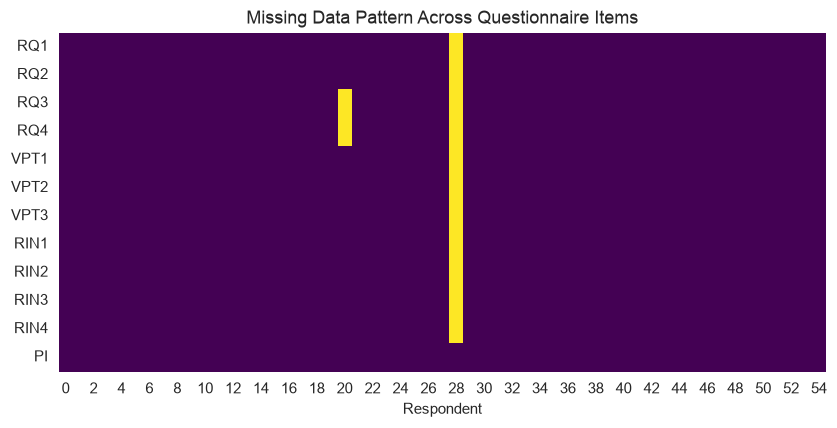

In [13]:
missing = pd.DataFrame({
    'n_missing': df[likert_items + ['PI']].isna().sum(),
    'pct_missing': (df[likert_items + ['PI']].isna().mean() * 100).round(2)
})
print("Missing values by item:")
print(missing)

print(f"\nRespondents with complete data on all {len(likert_items)} items: "
      f"{df[likert_items].notna().all(axis=1).sum()} of {len(df)}")

# Visualise the missing-data pattern
plt.figure(figsize=(9, 4))
sns.heatmap(df[likert_items + ['PI']].isna().T, cbar=False, cmap='viridis')
plt.title('Missing Data Pattern Across Questionnaire Items')
plt.xlabel('Respondent')
save_fig('01_missing_data_pattern')
plt.show()

In [14]:
# Person-mean substitution within construct, applied only where at least half the items
# of that construct were answered by that respondent
df_imp = df.copy()

for name, items in constructs.items():
    min_answered = int(np.ceil(len(items) / 2))
    answered = df_imp[items].notna().sum(axis=1)
    person_mean = df_imp[items].mean(axis=1)
    eligible = answered >= min_answered
    for it in items:
        fill_rows = df_imp[it].isna() & eligible
        df_imp.loc[fill_rows, it] = person_mean[fill_rows]
        if fill_rows.sum():
            print(f"{it}: {fill_rows.sum()} value(s) replaced by person mean")

print(f"\nRemaining missing values on the Likert items: {df_imp[likert_items].isna().sum().sum()}")
print(f"Remaining missing values on the dependent variable: {df_imp['PI'].isna().sum()}")

RQ3: 1 value(s) replaced by person mean
RQ4: 1 value(s) replaced by person mean

Remaining missing values on the Likert items: 11
Remaining missing values on the dependent variable: 0


### 2.7 Screening for careless / insufficient-effort responding

Anonymous online questionnaires are vulnerable to careless responding, where a respondent selects
the same option down an entire block of items without engaging with the content. The standard
detection statistic is the **longstring index**: the length of the longest run of identical
consecutive answers (Johnson, 2005; Meade and Craig, 2012).

Because a respondent may legitimately agree with every statement, careless responding is not
assumed from the longstring index alone. Instead, respondents are flagged only where **both** of
the following hold:

1. an identical answer was given to **all eleven** attitudinal items, and
2. the pattern is **internally inconsistent** with their reported behaviour (for example, selecting
   "Strongly Disagree" to every statement about the value of reviews while also reporting that they
   "Always" read reviews before purchasing).

Flagged cases are **retained in the main analysis** and used in a sensitivity analysis in Section 9,
so that the influence of the decision on the conclusions is transparent rather than hidden.

Distribution of the longstring index:
longstring
0      1
1      1
2     11
3      8
4     13
5      3
6      2
7      2
9      2
11    12
Name: count, dtype: int64

Respondents giving an identical answer to all 11 items: 12
Of those, flagged as internally inconsistent: 2


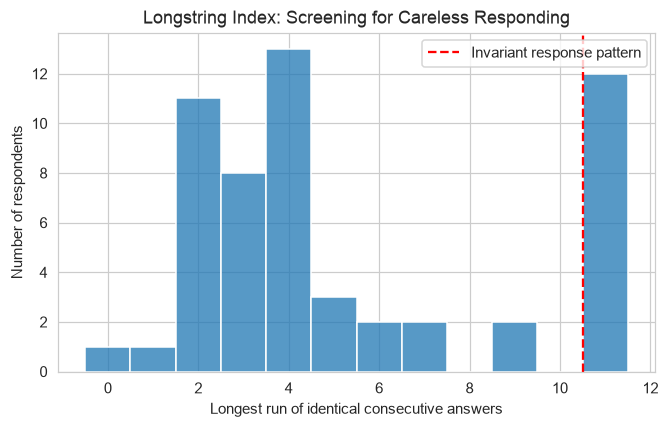

In [15]:
def longstring(row):
    """Return the length of the longest run of identical consecutive responses."""
    vals = row.dropna().values
    if len(vals) == 0:
        return 0
    best = current = 1
    for i in range(1, len(vals)):
        current = current + 1 if vals[i] == vals[i - 1] else 1
        best = max(best, current)
    return best

df_imp['longstring'] = df_imp[likert_items].apply(longstring, axis=1)
df_imp['item_sd'] = df_imp[likert_items].std(axis=1)

print("Distribution of the longstring index:")
print(df_imp['longstring'].value_counts().sort_index())

# Flag: identical answer to all 11 items AND inconsistent with reported review-reading behaviour
invariant = df_imp['longstring'] == len(likert_items)
inconsistent = invariant & (df_imp[likert_items].mean(axis=1) <= 2) & (df_imp['review_read_n'] >= 4)
df_imp['careless_flag'] = inconsistent.astype(int)

print(f"\nRespondents giving an identical answer to all {len(likert_items)} items: {invariant.sum()}")
print(f"Of those, flagged as internally inconsistent: {df_imp['careless_flag'].sum()}")

plt.figure(figsize=(7, 4))
sns.histplot(df_imp['longstring'], bins=range(1, len(likert_items) + 2), discrete=True)
plt.axvline(len(likert_items) - 0.5, color='red', linestyle='--', label='Invariant response pattern')
plt.title('Longstring Index: Screening for Careless Responding')
plt.xlabel('Longest run of identical consecutive answers')
plt.ylabel('Number of respondents')
plt.legend()
save_fig('02_longstring_screening')
plt.show()

### 2.8 Exporting the cleaned analytical dataset

The cleaned dataset is written to CSV. This file, together with this notebook, is deposited in the
project GitHub repository so that the analysis is fully reproducible, as required by the module
assessment brief. The two open-ended questions are excluded from the exported analytical file:
they are not analysed in this project, which retains a wholly quantitative Business Analytics
methodology.

In [16]:
analysis_cols = (['age', 'gender', 'employment', 'country', 'shop_freq', 'platform',
                  'monthly_spend', 'review_read_freq', 'reviews_read_n', 'key_review_feature',
                  'returned_product', 'bought_without_reviews']
                 + likert_items
                 + ['PI', 'shop_freq_n', 'review_read_n', 'reviews_read_num', 'spend_n',
                    'review_reliance', 'returned_n', 'longstring', 'careless_flag'])

clean = df_imp[analysis_cols].copy()
clean.to_csv('cleaned_survey_data.csv', index=False)
item_wording.to_csv('variable_codebook.csv', index=False)

print(f"Cleaned dataset exported: {clean.shape[0]} responses x {clean.shape[1]} variables")
print("Files written: cleaned_survey_data.csv, variable_codebook.csv")
clean.head()

Cleaned dataset exported: 55 responses x 32 variables
Files written: cleaned_survey_data.csv, variable_codebook.csv


,age,gender,employment,country,shop_freq,platform,monthly_spend,review_read_freq,reviews_read_n,key_review_feature,returned_product,bought_without_reviews,RQ1,RQ2,RQ3,RQ4,VPT1,VPT2,VPT3,RIN1,RIN2,RIN3,RIN4,PI,shop_freq_n,review_read_n,reviews_read_num,spend_n,review_reliance,returned_n,longstring,careless_flag
0,18–24,Female,Part-time employed,United Kingdom,Monthly,SHEIN,Less than £50,Often,4–6,Customer Photos,No,Rarely,3.0,5.0,5.0,5.0,3.0,4.0,3.0,5.0,5.0,4.0,4.0,1,3,4,2,1,3,0,3,0
1,18–24,Male,Student,United Kingdom,More than once a week,Amazon,Less than £50,Always,1–3,Star Rating,Yes,Frequently,5.0,5.0,5.0,5.0,1.0,3.0,4.0,1.0,3.0,2.0,5.0,3,5,5,1,1,1,1,4,0
2,25–34,Female,Full-time employed,India,Weekly,IKEA,£251–£500,Rarely,1–3,Helpful Votes,Yes,Rarely,3.0,4.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0,3.0,4,4,2,1,4,3,1,4,0
3,18–24,Male,Student,India,Every few months,Amazon,£50–£100,Always,1–3,Verified Purchase Badge,No,Sometimes,3.0,3.0,4.0,2.0,2.0,2.0,2.0,4.0,2.0,2.0,2.0,4,2,5,1,2,2,0,4,0
4,18–24,Male,Student,India,Weekly,Amazon,£50–£100,Always,4–6,Star Rating,Yes,Sometimes,5.0,5.0,5.0,5.0,4.0,5.0,2.0,4.0,4.0,4.0,4.0,4,4,5,2,2,2,1,4,0


---
## 3. Descriptive Statistics and Sample Profile

The sample profile establishes who the respondents are and therefore to whom the findings can
reasonably be generalised. It is reported in the dissertation as the opening section of Chapter 4.

In [17]:
n = len(clean)
print(f"Final analytical sample: n = {n}\n")

profile_vars = ['age', 'gender', 'employment', 'country', 'shop_freq',
                'platform', 'monthly_spend', 'review_read_freq', 'reviews_read_n',
                'key_review_feature', 'returned_product', 'bought_without_reviews']

frames = []
for v in profile_vars:
    counts = clean[v].value_counts(dropna=False)
    tab = pd.DataFrame({'Variable': v,
                        'Category': counts.index.astype(str),
                        'n': counts.values,
                        '%': (counts.values / n * 100).round(1)})
    frames.append(tab)

sample_profile = pd.concat(frames, ignore_index=True)
sample_profile.to_csv('table_01_sample_profile.csv', index=False)
sample_profile

Final analytical sample: n = 55



,Variable,Category,n,%
0,age,18–24,36,65.5
1,age,25–34,17,30.9
2,age,45–54,1,1.8
3,age,35–44,1,1.8
4,gender,Female,27,49.1
5,gender,Male,27,49.1
6,gender,Prefer not to say,1,1.8
7,employment,Student,25,45.5
8,employment,Full-time employed,20,36.4
9,employment,Part-time employed,4,7.3


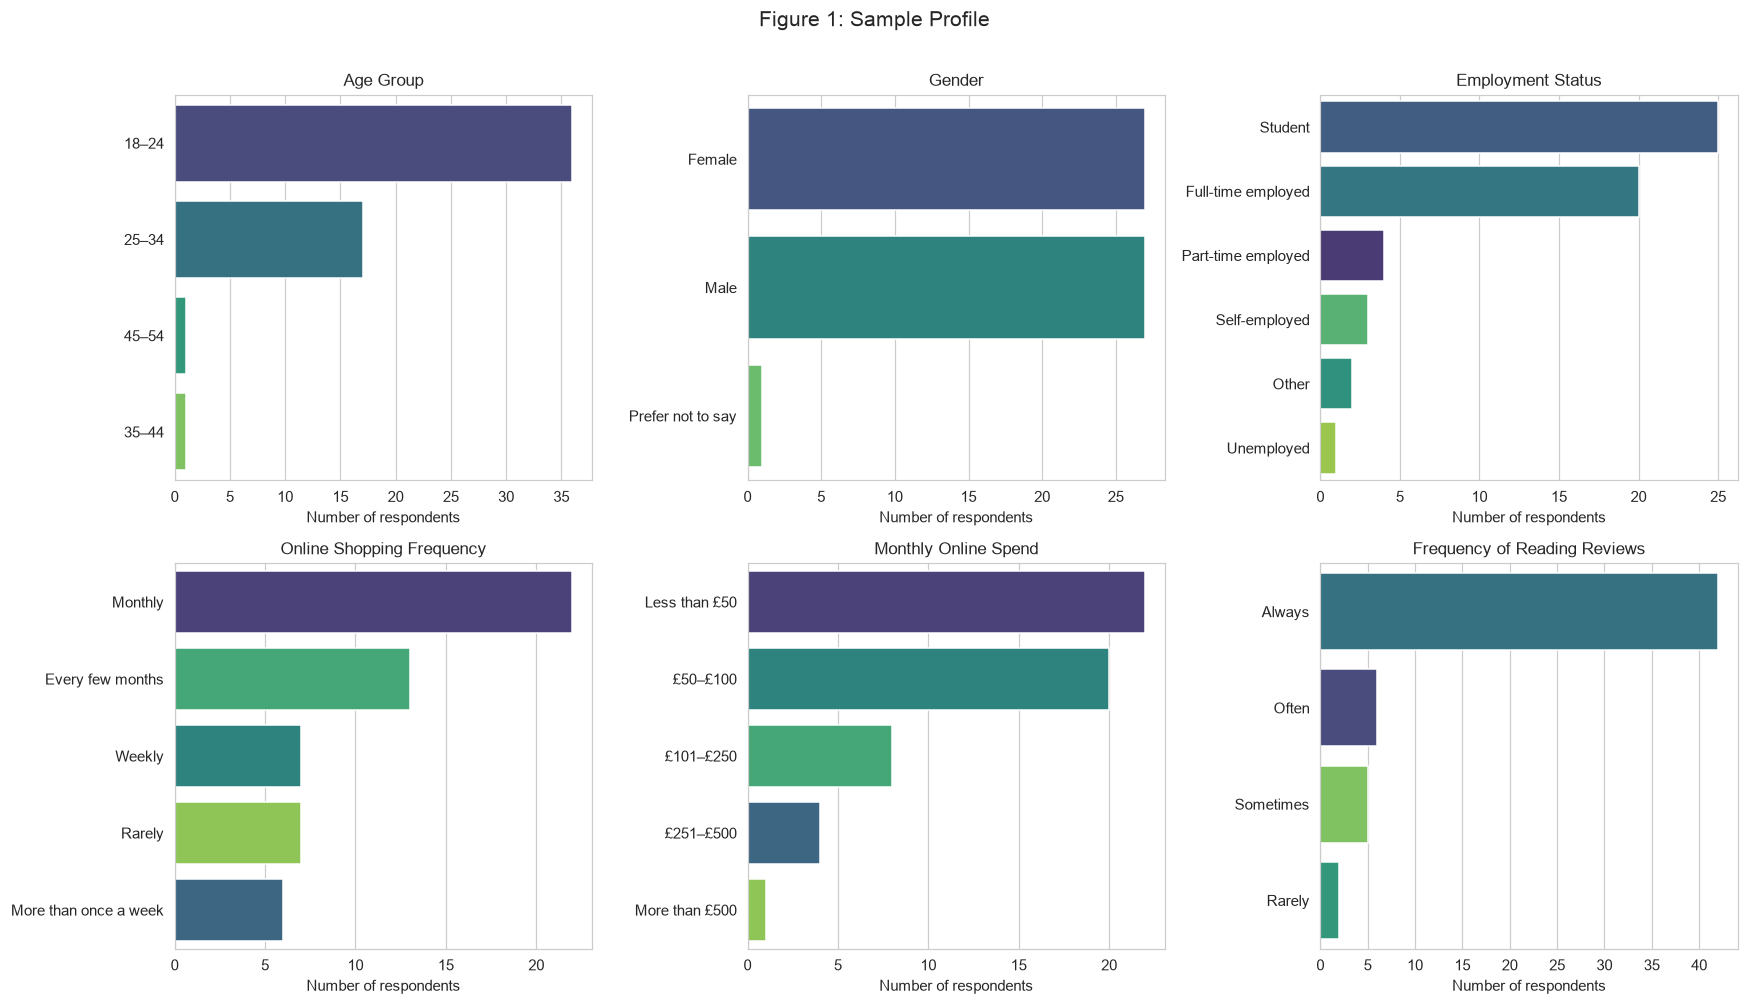

In [18]:
# Visualise the demographic and behavioural profile of the sample
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [('age', 'Age Group'), ('gender', 'Gender'), ('employment', 'Employment Status'),
              ('shop_freq', 'Online Shopping Frequency'), ('monthly_spend', 'Monthly Online Spend'),
              ('review_read_freq', 'Frequency of Reading Reviews')]

for ax, (col, title) in zip(axes.flatten(), plot_specs):
    order = clean[col].value_counts().index
    sns.countplot(y=clean[col], order=order, ax=ax, palette='viridis', hue=clean[col],
                  legend=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Number of respondents')
    ax.set_ylabel('')

plt.suptitle('Figure 1: Sample Profile', fontsize=14, y=1.01)
plt.tight_layout()
save_fig('03_sample_profile')
plt.show()

In [19]:
# Item-level descriptive statistics for all eleven attitudinal items and the dependent variable
item_desc = clean[likert_items + ['PI']].describe().T
item_desc['skew'] = clean[likert_items + ['PI']].skew()
item_desc['kurtosis'] = clean[likert_items + ['PI']].kurtosis()
item_desc = item_desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
                       'skew', 'kurtosis']].round(3)
item_desc.to_csv('table_02_item_descriptives.csv')
print("Item-level descriptive statistics")
item_desc

Item-level descriptive statistics


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
RQ1,54.0,3.815,1.117,1.0,3.0,4.0,5.000,5.0,-0.968,0.774
RQ2,54.0,4.074,1.211,1.0,4.0,4.5,5.000,5.0,-1.339,0.984
RQ3,54.0,3.806,1.057,1.0,3.0,4.0,4.875,5.0,-0.995,0.902
RQ4,54.0,3.620,1.285,1.0,3.0,4.0,5.000,5.0,-0.742,-0.351
VPT1,54.0,3.500,1.161,1.0,3.0,4.0,4.000,5.0,-0.788,0.217
VPT2,54.0,3.796,1.155,1.0,3.0,4.0,5.000,5.0,-0.804,-0.004
VPT3,54.0,3.389,1.071,1.0,3.0,3.0,4.000,5.0,-0.369,-0.281
RIN1,54.0,3.778,1.093,1.0,3.0,4.0,4.750,5.0,-1.068,1.022
RIN2,54.0,3.759,1.027,1.0,3.0,4.0,4.750,5.0,-0.686,0.300
RIN3,54.0,3.648,1.012,1.0,3.0,4.0,4.000,5.0,-0.705,0.269


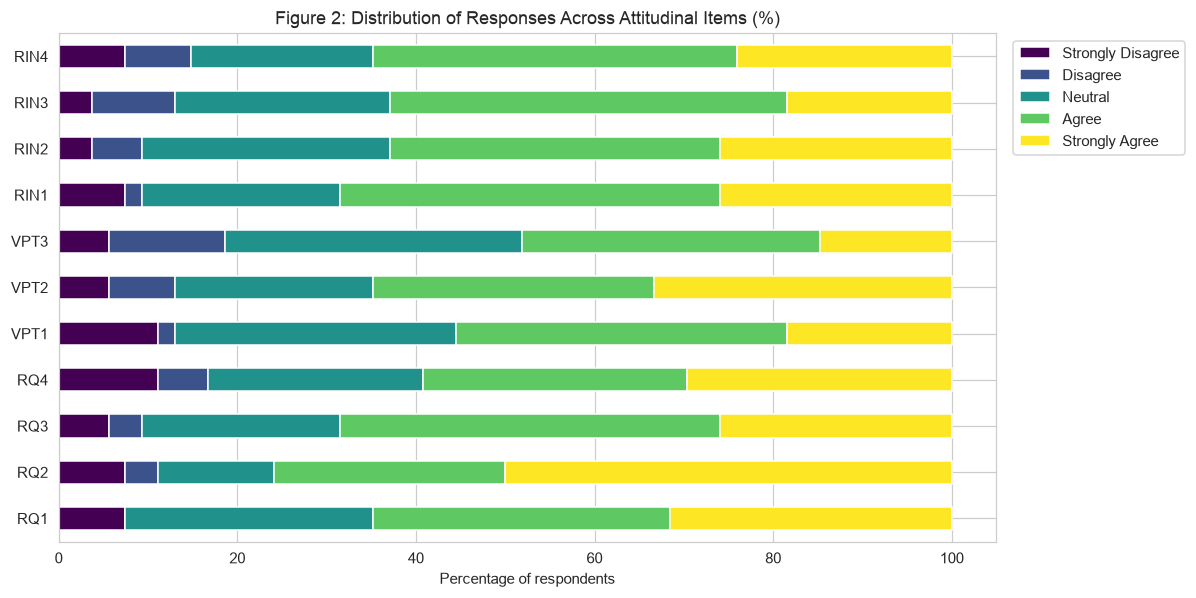

,Strongly Disagree,Disagree,Neutral,Agree,Strongly Agree
RQ1,7.4,0.0,27.8,33.3,31.5
RQ2,7.4,3.7,13.0,25.9,50.0
RQ3,5.6,3.7,22.2,42.6,25.9
RQ4,11.1,5.6,24.1,29.6,29.6
VPT1,11.1,1.9,31.5,37.0,18.5
VPT2,5.6,7.4,22.2,31.5,33.3
VPT3,5.6,13.0,33.3,33.3,14.8
RIN1,7.4,1.9,22.2,42.6,25.9
RIN2,3.7,5.6,27.8,37.0,25.9
RIN3,3.7,9.3,24.1,44.4,18.5


In [20]:
# Distribution of responses across the five-point scale, item by item
resp_dist = pd.DataFrame(index=likert_items,
                         columns=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree',
                                  'Strongly Agree'])
for item in likert_items:
    counts = clean[item].round().value_counts(normalize=True) * 100
    for code, label in zip(range(1, 6), resp_dist.columns):
        resp_dist.loc[item, label] = round(counts.get(code, 0), 1)

resp_dist = resp_dist.astype(float)
resp_dist.plot(kind='barh', stacked=True, figsize=(11, 6), colormap='viridis')
plt.title('Figure 2: Distribution of Responses Across Attitudinal Items (%)')
plt.xlabel('Percentage of respondents')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
save_fig('04_response_distribution')
plt.show()
resp_dist

---
## 4. Reliability Analysis of the Multi-Item Constructs

Before composite scores are computed, the internal consistency of each multi-item construct must be
established. Cronbach's alpha is the standard coefficient for this purpose. Following Nunnally and
Bernstein (1994), alpha of 0.70 or above is regarded as acceptable for research purposes, and 0.80
or above as good.

In addition to alpha, two diagnostics are reported for each item:

* the **corrected item-total correlation**, which should exceed 0.30 if the item belongs with the
  rest of the scale, and
* **alpha if the item were deleted**, which identifies items that weaken the scale.

In [21]:
def cronbach_alpha(data):
    """Compute Cronbach's alpha for a dataframe of scale items (listwise complete cases)."""
    d = data.dropna()
    k = d.shape[1]
    if k < 2:
        return np.nan
    item_var = d.var(axis=0, ddof=1).sum()
    total_var = d.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)


def reliability_report(data, construct_name):
    """Return alpha plus item-total correlations and alpha-if-deleted for each item."""
    d = data.dropna()
    alpha = cronbach_alpha(d)
    rows = []
    for item in d.columns:
        rest = d.drop(columns=[item]).sum(axis=1)
        corrected_itc = d[item].corr(rest)                 # corrected item-total correlation
        alpha_deleted = cronbach_alpha(d.drop(columns=[item]))
        rows.append({'Construct': construct_name, 'Item': item,
                     'Mean': round(d[item].mean(), 3), 'SD': round(d[item].std(), 3),
                     'Corrected item-total r': round(corrected_itc, 3),
                     'Alpha if item deleted': round(alpha_deleted, 3)})
    return alpha, pd.DataFrame(rows)


construct_labels = {'RQ':  'Perceived Review Quality',
                    'VPT': 'Trust in Verified-Purchase Reviews',
                    'RIN': 'Perceived Review Influence'}

alpha_summary, item_reports = [], []
for code, items in constructs.items():
    a, rep = reliability_report(clean[items], construct_labels[code])
    alpha_summary.append({'Construct': construct_labels[code], 'Code': code,
                          'No. of items': len(items), "Cronbach's alpha": round(a, 3),
                          'Interpretation': ('Excellent' if a >= .90 else 'Good' if a >= .80
                                             else 'Acceptable' if a >= .70 else 'Questionable')})
    item_reports.append(rep)

alpha_table = pd.DataFrame(alpha_summary)
item_table = pd.concat(item_reports, ignore_index=True)

alpha_table.to_csv('table_03_reliability.csv', index=False)
item_table.to_csv('table_04_item_analysis.csv', index=False)

print("Table 3: Reliability of the multi-item constructs")
display(alpha_table)
print("\nTable 4: Item-level reliability diagnostics")
display(item_table)

Table 3: Reliability of the multi-item constructs


,Construct,Code,No. of items,Cronbach's alpha,Interpretation
0,Perceived Review Quality,RQ,4,0.897,Good
1,Trust in Verified-Purchase Reviews,VPT,3,0.831,Good
2,Perceived Review Influence,RIN,4,0.888,Good



Table 4: Item-level reliability diagnostics


,Construct,Item,Mean,SD,Corrected item-total r,Alpha if item deleted
0,Perceived Review Quality,RQ1,3.815,1.117,0.787,0.862
1,Perceived Review Quality,RQ2,4.074,1.211,0.787,0.861
2,Perceived Review Quality,RQ3,3.806,1.057,0.781,0.866
3,Perceived Review Quality,RQ4,3.620,1.285,0.745,0.880
4,Trust in Verified-Purchase Reviews,VPT1,3.500,1.161,0.745,0.711
5,Trust in Verified-Purchase Reviews,VPT2,3.796,1.155,0.845,0.602
6,Trust in Verified-Purchase Reviews,VPT3,3.389,1.071,0.510,0.927
7,Perceived Review Influence,RIN1,3.778,1.093,0.738,0.862
8,Perceived Review Influence,RIN2,3.759,1.027,0.741,0.861
9,Perceived Review Influence,RIN3,3.648,1.012,0.865,0.816


### 4.1 Computing composite scores

Because each construct demonstrates acceptable internal consistency, the items of each construct
are averaged into a composite score. The mean, rather than the sum, is used so that all composites
remain on the original one-to-five metric and are therefore directly comparable with each other and
with the dependent variable.

In [22]:
for code, items in constructs.items():
    clean[code] = clean[items].mean(axis=1)

model_vars = ['RQ', 'VPT', 'RIN', 'PI']

comp_desc = clean[model_vars].describe().T
comp_desc['skew'] = clean[model_vars].skew()
comp_desc['kurtosis'] = clean[model_vars].kurtosis()
comp_desc = comp_desc.round(3)
comp_desc.to_csv('table_05_composite_descriptives.csv')

print("Table 5: Descriptive statistics for the composite variables")
display(comp_desc)

Table 5: Descriptive statistics for the composite variables


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
RQ,54.0,3.829,1.023,1.0,3.50,4.000,4.50,5.0,-1.338,1.522
VPT,54.0,3.562,0.977,1.0,3.00,3.667,4.00,5.0,-0.825,0.515
RIN,54.0,3.713,0.927,1.0,3.25,4.000,4.25,5.0,-0.967,1.227
PI,55.0,3.509,0.879,1.0,3.00,4.000,4.00,5.0,-1.046,1.908


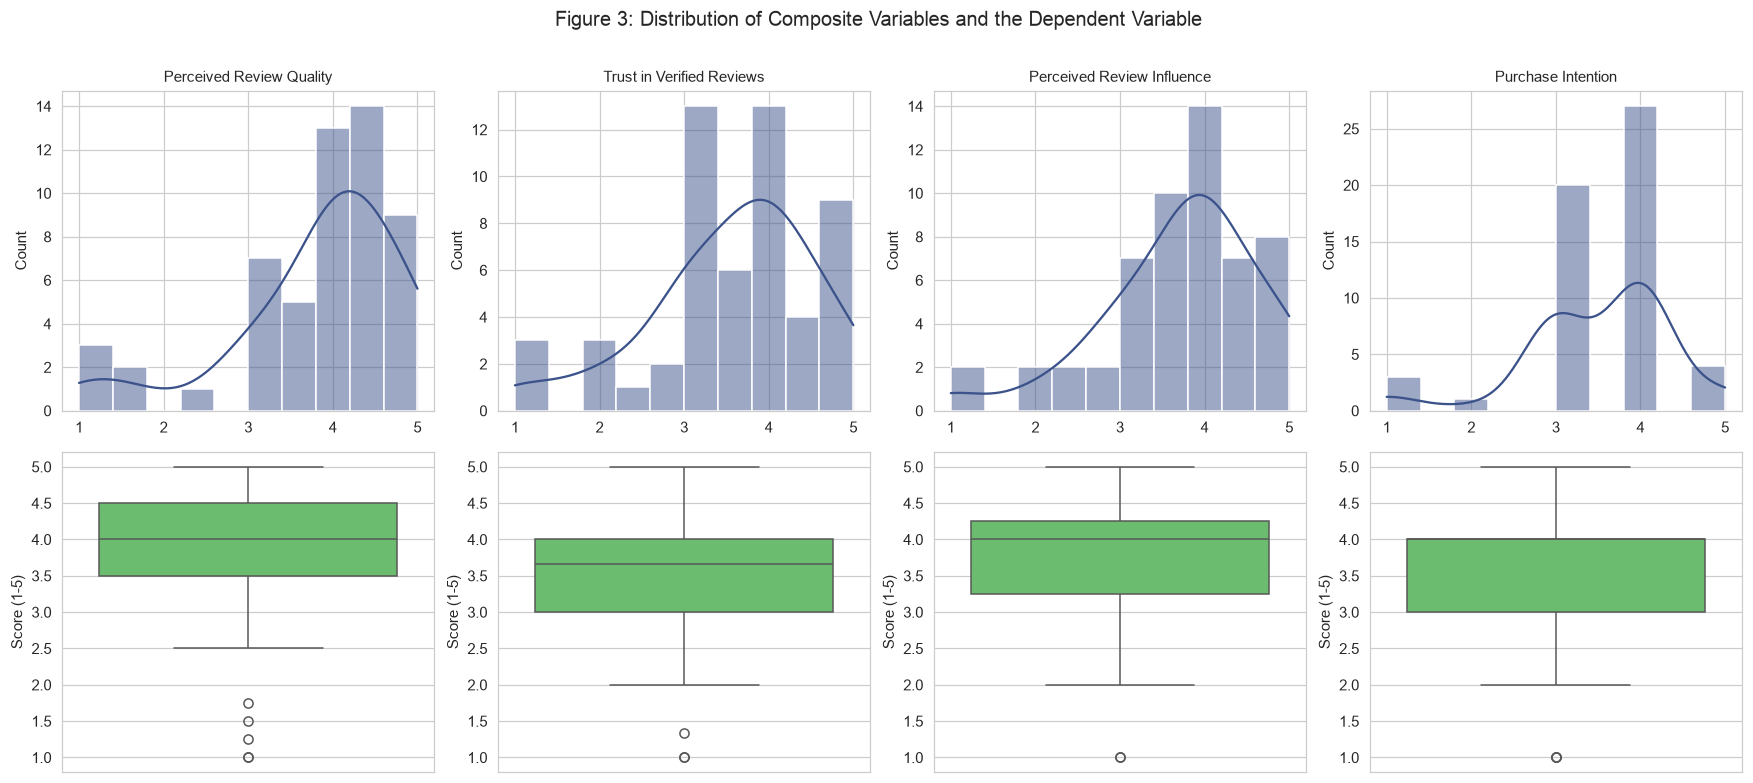

In [23]:
# Examine the distribution of each composite and of the dependent variable
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
labels = {'RQ': 'Perceived Review Quality', 'VPT': 'Trust in Verified Reviews',
          'RIN': 'Perceived Review Influence', 'PI': 'Purchase Intention'}

for j, v in enumerate(model_vars):
    sns.histplot(clean[v], kde=True, bins=10, ax=axes[0, j], color='#3b528b')
    axes[0, j].set_title(labels[v], fontsize=10)
    axes[0, j].set_xlabel('')
    sns.boxplot(y=clean[v], ax=axes[1, j], color='#5ec962')
    axes[1, j].set_ylabel('Score (1-5)')

plt.suptitle('Figure 3: Distribution of Composite Variables and the Dependent Variable',
             fontsize=13, y=1.01)
plt.tight_layout()
save_fig('05_composite_distributions')
plt.show()

In [24]:
# Formal test of normality for each variable entering the regression model
norm_rows = []
for v in model_vars:
    s = clean[v].dropna()
    sw = stats.shapiro(s)
    norm_rows.append({'Variable': labels[v], 'Code': v, 'n': len(s),
                      'Skewness': round(s.skew(), 3), 'Kurtosis': round(s.kurtosis(), 3),
                      'Shapiro-Wilk W': round(sw.statistic, 4),
                      'p-value': round(sw.pvalue, 4),
                      'Normality': 'Not rejected' if sw.pvalue > .05 else 'Rejected'})

normality_table = pd.DataFrame(norm_rows)
normality_table.to_csv('table_06_normality.csv', index=False)
print("Table 6: Tests of univariate normality")
normality_table

Table 6: Tests of univariate normality


,Variable,Code,n,Skewness,Kurtosis,Shapiro-Wilk W,p-value,Normality
0,Perceived Review Quality,RQ,54,-1.338,1.522,0.8538,0.0000,Rejected
1,Trust in Verified Reviews,VPT,54,-0.825,0.515,0.9310,0.0040,Rejected
2,Perceived Review Influence,RIN,54,-0.967,1.227,0.9210,0.0016,Rejected
3,Purchase Intention,PI,55,-1.046,1.908,0.8070,0.0000,Rejected


---
## 5. Correlation Analysis

Correlation analysis establishes the bivariate relationships between the three attitudinal
constructs and reported purchase intention, and provides an early indication of whether
multicollinearity is likely to be a problem in the regression models.

Both **Pearson's r** (appropriate for interval-scaled composites) and **Spearman's rho** (which
makes no distributional assumption and respects the ordinal origin of Likert data) are reported.
Where the two coefficients agree, confidence in the finding is strengthened.

In [25]:
corr_vars = model_vars + ['review_reliance', 'review_read_n', 'reviews_read_num', 'spend_n']

pearson_matrix = clean[corr_vars].corr(method='pearson').round(3)
spearman_matrix = clean[corr_vars].corr(method='spearman').round(3)

print("Pearson correlation matrix")
display(pearson_matrix)
print("\nSpearman correlation matrix")
display(spearman_matrix)

pearson_matrix.to_csv('table_07_pearson_correlations.csv')
spearman_matrix.to_csv('table_08_spearman_correlations.csv')

Pearson correlation matrix


,RQ,VPT,RIN,PI,review_reliance,review_read_n,reviews_read_num,spend_n
RQ,1.000,0.743,0.667,-0.093,-0.118,-0.074,0.058,-0.212
VPT,0.743,1.000,0.834,0.130,0.104,0.001,0.127,0.041
RIN,0.667,0.834,1.000,0.122,0.146,-0.027,0.128,-0.042
PI,-0.093,0.130,0.122,1.000,0.242,0.136,0.168,0.241
review_reliance,-0.118,0.104,0.146,0.242,1.000,0.151,0.190,0.000
review_read_n,-0.074,0.001,-0.027,0.136,0.151,1.000,0.460,-0.096
reviews_read_num,0.058,0.127,0.128,0.168,0.190,0.460,1.000,0.006
spend_n,-0.212,0.041,-0.042,0.241,0.000,-0.096,0.006,1.000



Spearman correlation matrix


,RQ,VPT,RIN,PI,review_reliance,review_read_n,reviews_read_num,spend_n
RQ,1.000,0.552,0.437,-0.046,-0.125,-0.064,0.072,-0.159
VPT,0.552,1.000,0.740,0.190,0.151,0.092,0.134,0.084
RIN,0.437,0.740,1.000,0.170,0.181,0.003,0.170,0.039
PI,-0.046,0.190,0.170,1.000,0.307,0.106,0.127,0.232
review_reliance,-0.125,0.151,0.181,0.307,1.000,0.109,0.204,-0.028
review_read_n,-0.064,0.092,0.003,0.106,0.109,1.000,0.455,-0.101
reviews_read_num,0.072,0.134,0.170,0.127,0.204,0.455,1.000,-0.088
spend_n,-0.159,0.084,0.039,0.232,-0.028,-0.101,-0.088,1.000


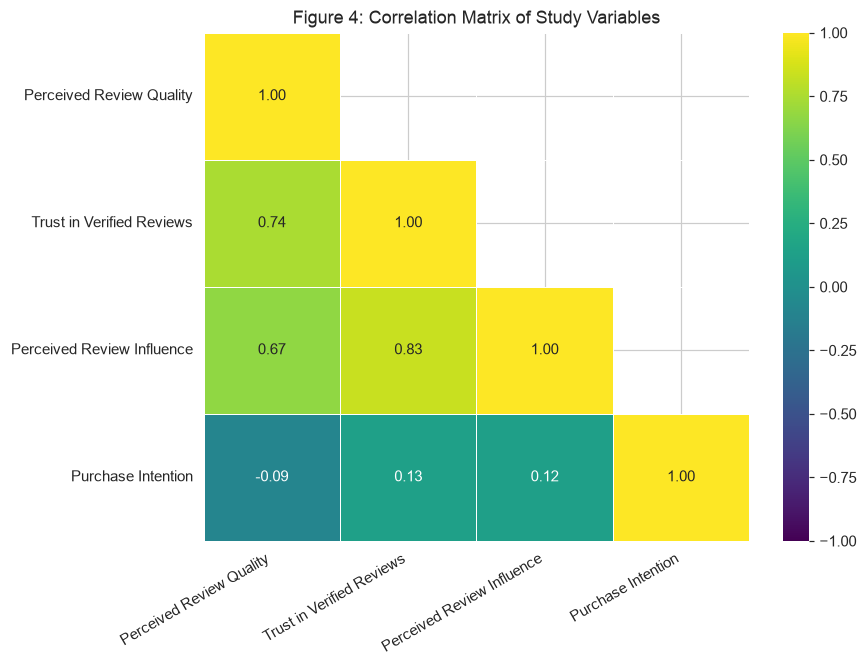

In [26]:
# Produce a heatmap showing the correlation between the main variables in the dataset
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(clean[model_vars].corr(), dtype=bool), k=1)
sns.heatmap(clean[model_vars].corr(), annot=True, cmap='viridis', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            xticklabels=[labels[v] for v in model_vars],
            yticklabels=[labels[v] for v in model_vars])
plt.title('Figure 4: Correlation Matrix of Study Variables')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
save_fig('06_correlation_heatmap')
plt.show()

In [27]:
# Formal significance testing of each correlation with the dependent variable
corr_rows = []
for v in ['RQ', 'VPT', 'RIN', 'review_reliance', 'review_read_n', 'reviews_read_num', 'spend_n']:
    d = clean[[v, 'PI']].dropna()
    r, p_r = pearsonr(d[v], d['PI'])
    rho, p_s = spearmanr(d[v], d['PI'])
    corr_rows.append({'Predictor': labels.get(v, v), 'n': len(d),
                      "Pearson r": round(r, 3), 'p (Pearson)': round(p_r, 4),
                      "Spearman rho": round(rho, 3), 'p (Spearman)': round(p_s, 4),
                      'Significant at .05': 'Yes' if min(p_r, p_s) < .05 else 'No'})

corr_with_dv = pd.DataFrame(corr_rows)
corr_with_dv.to_csv('table_09_correlations_with_DV.csv', index=False)
print("Table 9: Correlations with purchase intention")
corr_with_dv

Table 9: Correlations with purchase intention


,Predictor,n,Pearson r,p (Pearson),Spearman rho,p (Spearman),Significant at .05
0,Perceived Review Quality,54,-0.093,0.5043,-0.046,0.7401,No
1,Trust in Verified Reviews,54,0.130,0.3504,0.190,0.1689,No
2,Perceived Review Influence,54,0.122,0.3810,0.170,0.2193,No
3,review_reliance,55,0.242,0.0746,0.307,0.0225,Yes
4,review_read_n,55,0.136,0.3234,0.106,0.4423,No
5,reviews_read_num,55,0.168,0.2208,0.127,0.3549,No
6,spend_n,55,0.241,0.0764,0.232,0.0887,No


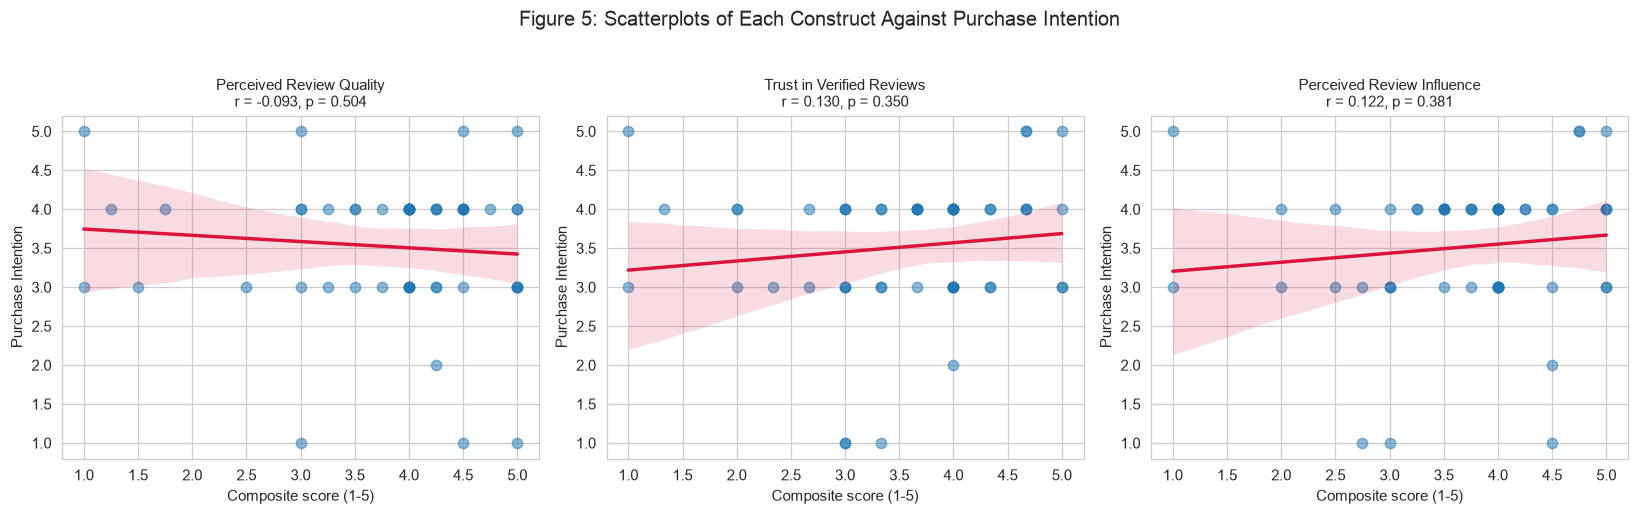

In [28]:
# Let's visualise the relationship between each construct and the dependent variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, v in zip(axes, ['RQ', 'VPT', 'RIN']):
    sns.regplot(x=clean[v], y=clean['PI'], ci=95, ax=ax,
                scatter_kws={'alpha': 0.5, 's': 45}, line_kws={'color': 'crimson'})
    r, p = pearsonr(clean[[v, 'PI']].dropna()[v], clean[[v, 'PI']].dropna()['PI'])
    ax.set_title(f"{labels[v]}\nr = {r:.3f}, p = {p:.3f}", fontsize=10)
    ax.set_xlabel('Composite score (1-5)')
    ax.set_ylabel('Purchase Intention')

plt.suptitle('Figure 5: Scatterplots of Each Construct Against Purchase Intention',
             fontsize=13, y=1.03)
plt.tight_layout()
save_fig('07_scatterplots_constructs_vs_PI')
plt.show()

---
## 6. Simple Linear Regression

Each construct is first regressed on purchase intention individually. This establishes the
unadjusted effect of each predictor before the constructs are entered together, and follows the
analytical sequence taught on the programme.

* **Dependent variable:** PI (purchase intention)
* **Independent variables (entered separately):** RQ, VPT, RIN

In [29]:
simple_results = []
for v in ['RQ', 'VPT', 'RIN']:
    d = clean[[v, 'PI']].dropna()
    X = sm.add_constant(d[v])          # add constant for intercept
    y = d['PI']
    m = sm.OLS(y, X).fit()
    print(f"\n{'=' * 78}\nSIMPLE LINEAR REGRESSION: {labels[v]} -> Purchase Intention\n{'=' * 78}")
    print(m.summary())
    simple_results.append({'Predictor': labels[v], 'b': round(m.params[v], 3),
                           'SE': round(m.bse[v], 3), 't': round(m.tvalues[v], 3),
                           'p': round(m.pvalues[v], 4), 'R-squared': round(m.rsquared, 4)})

simple_table = pd.DataFrame(simple_results)
simple_table.to_csv('table_10_simple_regressions.csv', index=False)
print("\nTable 10: Summary of the simple linear regressions")
simple_table


SIMPLE LINEAR REGRESSION: Perceived Review Quality -> Purchase Intention
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.4521
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.504
Time:                        16:07:28   Log-Likelihood:                -69.268
No. Observations:                  54   AIC:                             142.5
Df Residuals:                      52   BIC:                             146.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

,Predictor,b,SE,t,p,R-squared
0,Perceived Review Quality,-0.080,0.119,-0.672,0.5043,0.0086
1,Trust in Verified Reviews,0.117,0.124,0.942,0.3504,0.0168
2,Perceived Review Influence,0.116,0.131,0.884,0.3810,0.0148


---
## 7. Hierarchical Multiple Linear Regression

The predictors are now entered in blocks so that the incremental contribution of each construct can
be assessed. Given the sample size, the model is deliberately kept parsimonious: a maximum of four
predictors is entered, which maintains a ratio of roughly thirteen cases per predictor. Demographic
controls are not included, since adding them would over-specify the model relative to the available
degrees of freedom.

* **Model 1:** Perceived Review Quality
* **Model 2:** + Trust in Verified-Purchase Reviews
* **Model 3:** + Perceived Review Influence
* **Model 4:** + Behavioural review reliance (added as a robustness extension)

Models are compared on R-squared, adjusted R-squared and the Akaike Information Criterion (AIC).
AIC measures model quality by balancing goodness of fit against model complexity; a lower AIC
suggests a better model as it penalises overfitting.

In [30]:
reg_data = clean[['RQ', 'VPT', 'RIN', 'review_reliance', 'PI']].dropna()
print(f"Cases available for the regression models: n = {len(reg_data)}")

model1 = ols("PI ~ RQ", data=reg_data).fit()
model2 = ols("PI ~ RQ + VPT", data=reg_data).fit()
model3 = ols("PI ~ RQ + VPT + RIN", data=reg_data).fit()
model4 = ols("PI ~ RQ + VPT + RIN + review_reliance", data=reg_data).fit()

print("\nOLS Regression Model 1: Perceived Review Quality")
print(model1.summary())

Cases available for the regression models: n = 54

OLS Regression Model 1: Perceived Review Quality
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.4521
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.504
Time:                        16:07:28   Log-Likelihood:                -69.268
No. Observations:                  54   AIC:                             142.5
Df Residuals:                      52   BIC:                             146.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [31]:
print("OLS Regression Model 2: adding Trust in Verified-Purchase Reviews")
print(model2.summary())

OLS Regression Model 2: adding Trust in Verified-Purchase Reviews
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     2.725
Date:                Sun, 23 Aug 2026   Prob (F-statistic):             0.0751
Time:                        16:07:28   Log-Likelihood:                -66.761
No. Observations:                  54   AIC:                             139.5
Df Residuals:                      51   BIC:                             145.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [32]:
print("OLS Regression Model 3: adding Perceived Review Influence (full attitudinal model)")
print(model3.summary())

OLS Regression Model 3: adding Perceived Review Influence (full attitudinal model)
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.859
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.149
Time:                        16:07:28   Log-Likelihood:                -66.647
No. Observations:                  54   AIC:                             141.3
Df Residuals:                      50   BIC:                             149.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [33]:
print("OLS Regression Model 4: adding behavioural review reliance")
print(model4.summary())

OLS Regression Model 4: adding behavioural review reliance
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.642
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.179
Time:                        16:07:28   Log-Likelihood:                -66.106
No. Observations:                  54   AIC:                             142.2
Df Residuals:                      49   BIC:                             152.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [34]:
# Comparing models based on R-squared, adjusted R-squared and AIC
comparison = pd.DataFrame({
    'Model': ['Model 1: RQ', 'Model 2: + VPT', 'Model 3: + RIN', 'Model 4: + review reliance'],
    'k (predictors)': [1, 2, 3, 4],
    'R-squared': [round(m.rsquared, 4) for m in (model1, model2, model3, model4)],
    'Adjusted R-squared': [round(m.rsquared_adj, 4) for m in (model1, model2, model3, model4)],
    'F': [round(m.fvalue, 3) for m in (model1, model2, model3, model4)],
    'p (F-test)': [round(m.f_pvalue, 4) for m in (model1, model2, model3, model4)],
    'AIC': [round(m.aic, 2) for m in (model1, model2, model3, model4)],
    'BIC': [round(m.bic, 2) for m in (model1, model2, model3, model4)],
})
comparison['Change in R-squared'] = comparison['R-squared'].diff().round(4)
comparison.to_csv('table_11_model_comparison.csv', index=False)

print("Table 11: Model comparison")
display(comparison)

# Formal test of whether each additional block improves the model significantly
print("\nIncremental F-tests (nested model comparisons):")
print(sm.stats.anova_lm(model1, model2, model3, model4))

Table 11: Model comparison


,Model,k (predictors),R-squared,Adjusted R-squared,F,p (F-test),AIC,BIC,Change in R-squared
0,Model 1: RQ,1,0.0086,-0.0104,0.452,0.5043,142.54,146.51,NaN
1,Model 2: + VPT,2,0.0965,0.0611,2.725,0.0751,139.52,145.49,0.0879
2,Model 3: + RIN,3,0.1003,0.0463,1.859,0.1486,141.29,149.25,0.0038
3,Model 4: + review reliance,4,0.1182,0.0462,1.642,0.1788,142.21,152.16,0.0179



Incremental F-tests (nested model comparisons):
   df_resid        ssr  df_diff   ss_diff         F    Pr(>F)
0      52.0  41.123944      0.0       NaN       NaN       NaN
1      51.0  37.477173      1.0  3.646771  4.885111  0.031603
2      50.0  37.319682      1.0  0.157491  0.210971  0.647998
3      49.0  36.578855      1.0  0.740827  0.992390  0.324053


In [35]:
# Coefficient table for the full attitudinal model, including standardised beta weights
def coef_table(fit, data):
    """Return unstandardised and standardised coefficients with 95% confidence intervals."""
    dv_sd = data[fit.model.endog_names].std()
    rows = []
    ci = fit.conf_int()
    for name in fit.params.index:
        if name == 'Intercept':
            beta = np.nan
        else:
            beta = fit.params[name] * data[name].std() / dv_sd
        rows.append({'Predictor': name,
                     'b': round(fit.params[name], 3),
                     'SE': round(fit.bse[name], 3),
                     'Beta': round(beta, 3) if not np.isnan(beta) else '',
                     't': round(fit.tvalues[name], 3),
                     'p': round(fit.pvalues[name], 4),
                     '95% CI lower': round(ci.loc[name, 0], 3),
                     '95% CI upper': round(ci.loc[name, 1], 3)})
    return pd.DataFrame(rows)

final_coefs = coef_table(model3, reg_data)
final_coefs.to_csv('table_12_final_model_coefficients.csv', index=False)
print("Table 12: Coefficients of the full attitudinal model (Model 3)")
final_coefs

Table 12: Coefficients of the full attitudinal model (Model 3)


,Predictor,b,SE,Beta,t,p,95% CI lower,95% CI upper
0,Intercept,3.402,0.519,,6.559,0.0000,2.360,4.444
1,RQ,-0.375,0.175,-0.434,-2.147,0.0367,-0.726,-0.024
2,VPT,0.324,0.247,0.358,1.313,0.1953,-0.172,0.820
3,RIN,0.107,0.234,0.113,0.459,0.6480,-0.362,0.577


---
## 8. Testing the Regression Assumptions

Ordinary least squares regression rests on a set of assumptions. Each is tested formally and
visually below; the results are reported in the methodology and findings chapters of the
dissertation.

| Assumption | Test applied |
|---|---|
| Linearity | Residuals-versus-fitted plot; Rainbow test |
| Homoscedasticity | Residual plot; Breusch-Pagan test |
| Normality of residuals | Histogram; Q-Q plot; Shapiro-Wilk test |
| Independence of residuals | Durbin-Watson statistic |
| No multicollinearity | Variance Inflation Factor (VIF); tolerance |
| No undue influence | Cook's distance; standardised residuals |

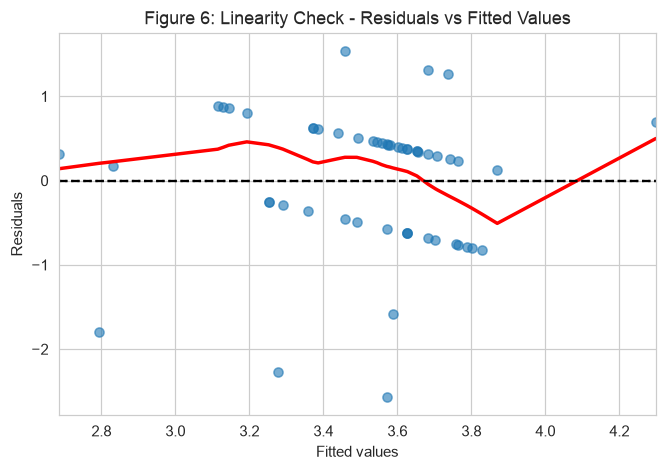

Rainbow test for linearity: F = 1.1837, p = 0.3430
Interpretation: linearity assumption not violated


In [36]:
final_model = model3          # the full attitudinal model is carried forward for diagnostics

# ASSUMPTION 1 - Linearity: residuals versus fitted values should show no systematic pattern
plt.figure(figsize=(7, 4.5))
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True,
              scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Figure 6: Linearity Check - Residuals vs Fitted Values')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
save_fig('08_linearity_residual_plot')
plt.show()

rainbow_stat, rainbow_p = linear_rainbow(final_model)
print(f"Rainbow test for linearity: F = {rainbow_stat:.4f}, p = {rainbow_p:.4f}")
print("Interpretation:", "linearity assumption not violated" if rainbow_p > .05
      else "evidence of non-linearity")

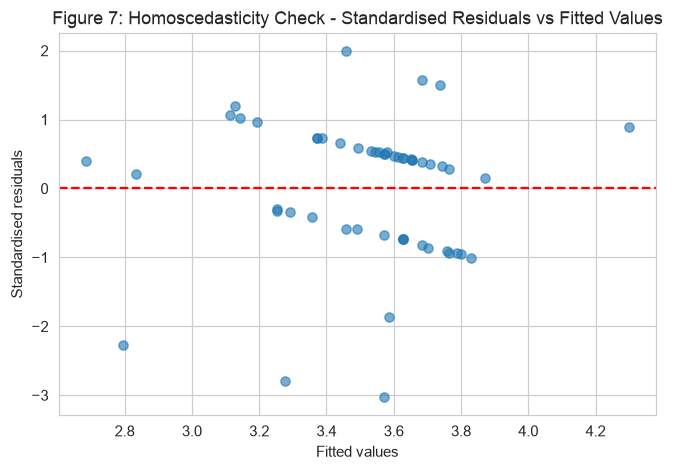

Breusch-Pagan test: LM statistic = 1.6161, p = 0.6557
Interpretation: homoscedasticity assumption satisfied


In [37]:
# ASSUMPTION 2 - Homoscedasticity: residuals should have constant variance.
# If the residuals show a funnel shape (widening or narrowing), heteroscedasticity may be present.
plt.figure(figsize=(7, 4.5))
plt.scatter(final_model.fittedvalues, final_model.get_influence().resid_studentized_internal,
            alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Figure 7: Homoscedasticity Check - Standardised Residuals vs Fitted Values')
plt.xlabel('Fitted values')
plt.ylabel('Standardised residuals')
save_fig('09_homoscedasticity_check')
plt.show()

bp = het_breuschpagan(final_model.resid, final_model.model.exog)
print(f"Breusch-Pagan test: LM statistic = {bp[0]:.4f}, p = {bp[1]:.4f}")
print("Interpretation:", "homoscedasticity assumption satisfied" if bp[1] > .05
      else "evidence of heteroscedasticity")

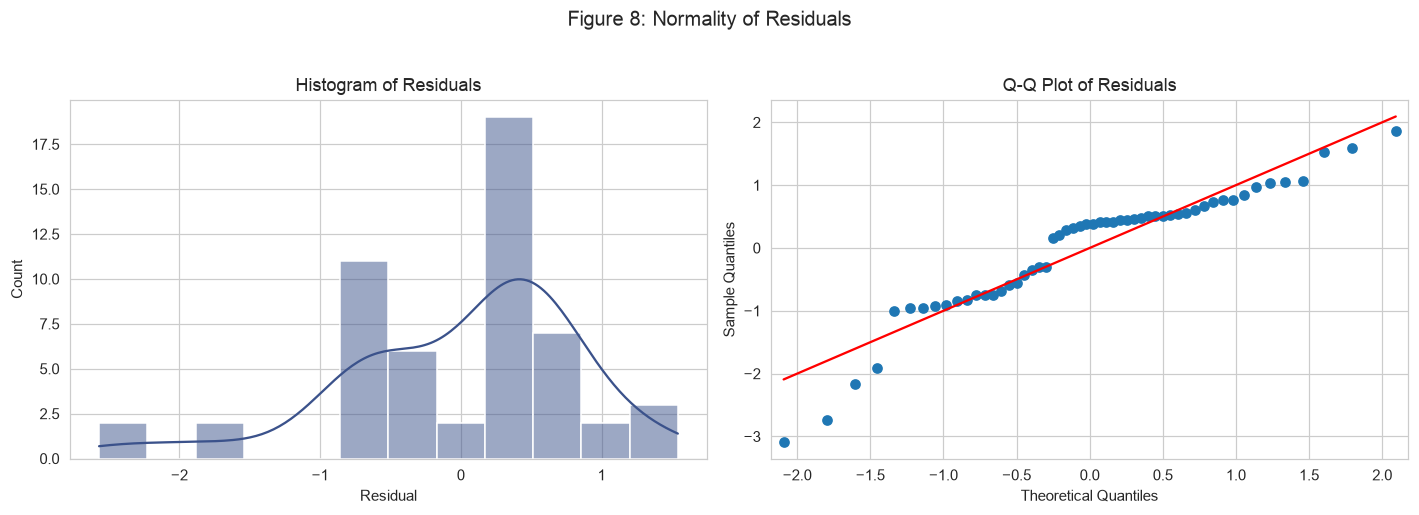

Shapiro-Wilk test on residuals: W = 0.9174, p = 0.0012
Interpretation: residuals depart from normality - non-parametric and ordinal robustness checks reported in Section 9


In [38]:
# ASSUMPTION 3 - Normality of residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(final_model.resid, kde=True, bins=12, ax=axes[0], color='#3b528b')
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residual')
sm.qqplot(final_model.resid, line='s', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.suptitle('Figure 8: Normality of Residuals', y=1.03, fontsize=13)
plt.tight_layout()
save_fig('10_residual_normality')
plt.show()

sw_resid = stats.shapiro(final_model.resid)
print(f"Shapiro-Wilk test on residuals: W = {sw_resid.statistic:.4f}, p = {sw_resid.pvalue:.4f}")
print("Interpretation:", "residuals approximately normal" if sw_resid.pvalue > .05
      else "residuals depart from normality - non-parametric and ordinal robustness checks reported "
           "in Section 9")

In [39]:
# ASSUMPTION 4 - Independence of residuals
dw = durbin_watson(final_model.resid)
print(f"Durbin-Watson statistic: {dw:.4f}")
print("Interpretation:", "acceptable, little evidence of autocorrelation" if 1.5 < dw < 2.5
      else "possible autocorrelation in residuals")

Durbin-Watson statistic: 1.3454
Interpretation: possible autocorrelation in residuals


In [40]:
# ASSUMPTION 5 - No multicollinearity among the predictors
X_vif = sm.add_constant(reg_data[['RQ', 'VPT', 'RIN']])
vif_table = pd.DataFrame({
    'Predictor': [labels[v] for v in ['RQ', 'VPT', 'RIN']],
    'VIF': [round(variance_inflation_factor(X_vif.values, i), 3) for i in range(1, X_vif.shape[1])],
})
vif_table['Tolerance'] = (1 / vif_table['VIF']).round(3)
vif_table['Assessment'] = np.where(vif_table['VIF'] < 5, 'Acceptable',
                                   np.where(vif_table['VIF'] < 10, 'Elevated', 'Serious concern'))
vif_table.to_csv('table_13_vif.csv', index=False)
print("Table 13: Multicollinearity diagnostics")
vif_table

Table 13: Multicollinearity diagnostics


,Predictor,VIF,Tolerance,Assessment
0,Perceived Review Quality,2.268,0.441,Acceptable
1,Trust in Verified Reviews,4.130,0.242,Acceptable
2,Perceived Review Influence,3.336,0.300,Acceptable


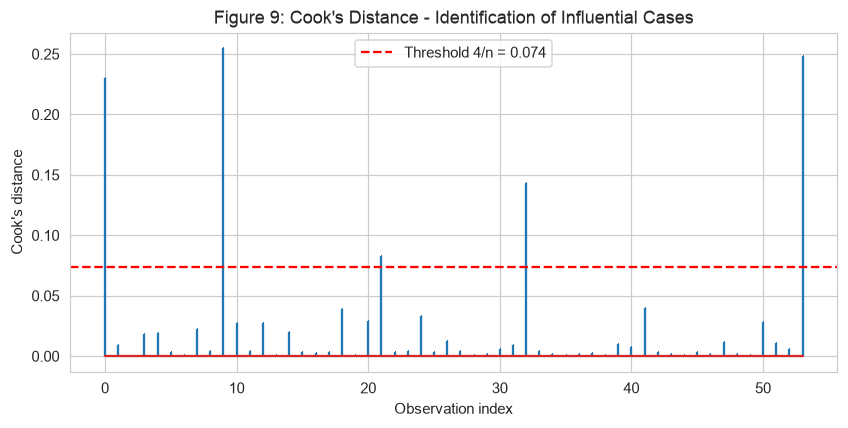

Observations exceeding the 4/n threshold: 5
Observations exceeding the conventional cut-off of 1: 0
Standardised residuals beyond +/- 3: 1


In [41]:
# ASSUMPTION 6 - Influential observations
influence = OLSInfluence(final_model)
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(reg_data)

plt.figure(figsize=(9, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold 4/n = {threshold:.3f}')
plt.title("Figure 9: Cook's Distance - Identification of Influential Cases")
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.legend()
save_fig('11_cooks_distance')
plt.show()

print(f"Observations exceeding the 4/n threshold: {(cooks_d > threshold).sum()}")
print(f"Observations exceeding the conventional cut-off of 1: {(cooks_d > 1).sum()}")
print(f"Standardised residuals beyond +/- 3: "
      f"{(np.abs(influence.resid_studentized_internal) > 3).sum()}")

---
## 9. Robustness and Sensitivity Analyses

Three robustness checks are conducted so that the conclusions do not depend on a single modelling
decision:

1. **Ordinal logistic regression**, which respects the ordinal measurement of the dependent
   variable and does not assume normally distributed residuals;
2. **Exclusion of flagged careless responders**, testing whether the data-quality decision taken in
   Section 2.7 changes the substantive conclusions;
3. **Bootstrapped confidence intervals**, which do not rely on the normality of the sampling
   distribution and are therefore well suited to a small sample.

In [42]:
# ROBUSTNESS CHECK 1 - Ordinal logistic regression (proportional odds model)
ord_data = reg_data.copy()
ord_data['PI_ord'] = ord_data['PI'].astype(int)

ord_model = OrderedModel(ord_data['PI_ord'], ord_data[['RQ', 'VPT', 'RIN']],
                         distr='logit').fit(method='bfgs', disp=False)
print(ord_model.summary())

odds = pd.DataFrame({
    'Predictor': [labels[v] for v in ['RQ', 'VPT', 'RIN']],
    'Coefficient': [round(ord_model.params[v], 3) for v in ['RQ', 'VPT', 'RIN']],
    'Odds ratio': [round(np.exp(ord_model.params[v]), 3) for v in ['RQ', 'VPT', 'RIN']],
    'p-value': [round(ord_model.pvalues[v], 4) for v in ['RQ', 'VPT', 'RIN']],
})
odds.to_csv('table_14_ordinal_logistic.csv', index=False)
print("\nTable 14: Ordinal logistic regression - odds ratios")
odds

                             OrderedModel Results                             
Dep. Variable:                 PI_ord   Log-Likelihood:                -59.350
Model:                   OrderedModel   AIC:                             132.7
Method:            Maximum Likelihood   BIC:                             146.6
Date:                Sun, 23 Aug 2026                                         
Time:                        16:07:29                                         
No. Observations:                  54                                         
Df Residuals:                      47                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RQ            -0.7308      0.399     -1.833      0.067      -1.512       0.051
VPT            0.5108      0.549      0.931      0.3

,Predictor,Coefficient,Odds ratio,p-value
0,Perceived Review Quality,-0.731,0.482,0.0668
1,Trust in Verified Reviews,0.511,1.667,0.3518
2,Perceived Review Influence,0.425,1.530,0.4203


In [43]:
# ROBUSTNESS CHECK 2 - Re-estimate the model excluding flagged careless responders
screened = clean[clean['careless_flag'] == 0][['RQ', 'VPT', 'RIN', 'PI']].dropna()
print(f"Full sample: n = {len(reg_data)}   |   Screened sample: n = {len(screened)}")

model_screened = ols("PI ~ RQ + VPT + RIN", data=screened).fit()
print(model_screened.summary())

sensitivity = pd.DataFrame({
    'Predictor': ['RQ', 'VPT', 'RIN'],
    'b (full sample)': [round(model3.params[v], 3) for v in ['RQ', 'VPT', 'RIN']],
    'p (full sample)': [round(model3.pvalues[v], 4) for v in ['RQ', 'VPT', 'RIN']],
    'b (screened)': [round(model_screened.params[v], 3) for v in ['RQ', 'VPT', 'RIN']],
    'p (screened)': [round(model_screened.pvalues[v], 4) for v in ['RQ', 'VPT', 'RIN']],
})
sensitivity.to_csv('table_15_sensitivity_analysis.csv', index=False)
print("\nTable 15: Sensitivity analysis - full versus screened sample")
display(sensitivity)
print(f"\nR-squared, full sample: {model3.rsquared:.4f}  |  screened sample: "
      f"{model_screened.rsquared:.4f}")

Full sample: n = 54   |   Screened sample: n = 52
                            OLS Regression Results                            
Dep. Variable:                     PI   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.176
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.103
Time:                        16:07:29   Log-Likelihood:                -62.989
No. Observations:                  52   AIC:                             134.0
Df Residuals:                      48   BIC:                             141.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
In

,Predictor,b (full sample),p (full sample),b (screened),p (screened)
0,RQ,-0.375,0.0367,-0.321,0.0756
1,VPT,0.324,0.1953,0.311,0.2053
2,RIN,0.107,0.6480,0.188,0.4343



R-squared, full sample: 0.1003  |  screened sample: 0.1197


In [44]:
# ROBUSTNESS CHECK 3 - Bootstrapped 95% confidence intervals for the regression coefficients
n_boot = 5000
boot_coefs = {v: [] for v in ['RQ', 'VPT', 'RIN']}

rng = np.random.default_rng(RANDOM_STATE)
for _ in range(n_boot):
    sample = reg_data.sample(n=len(reg_data), replace=True, random_state=rng.integers(1e9))
    try:
        fit_b = ols("PI ~ RQ + VPT + RIN", data=sample).fit()
        for v in boot_coefs:
            boot_coefs[v].append(fit_b.params[v])
    except Exception:
        continue

boot_table = pd.DataFrame([{
    'Predictor': labels[v],
    'Original b': round(model3.params[v], 3),
    'Bootstrap mean b': round(np.mean(boot_coefs[v]), 3),
    'Bootstrap 95% CI lower': round(np.percentile(boot_coefs[v], 2.5), 3),
    'Bootstrap 95% CI upper': round(np.percentile(boot_coefs[v], 97.5), 3),
    'CI excludes zero': 'Yes' if (np.percentile(boot_coefs[v], 2.5) > 0) or
                                 (np.percentile(boot_coefs[v], 97.5) < 0) else 'No',
} for v in ['RQ', 'VPT', 'RIN']])

boot_table.to_csv('table_16_bootstrap_ci.csv', index=False)
print(f"Table 16: Bootstrapped coefficient estimates ({n_boot} resamples)")
boot_table

Table 16: Bootstrapped coefficient estimates (5000 resamples)


,Predictor,Original b,Bootstrap mean b,Bootstrap 95% CI lower,Bootstrap 95% CI upper,CI excludes zero
0,Perceived Review Quality,-0.375,-0.358,-0.761,0.043,No
1,Trust in Verified Reviews,0.324,0.345,-0.124,0.981,No
2,Perceived Review Influence,0.107,0.078,-0.511,0.578,No


---
## 10. Supplementary Group Comparisons

Because the dependent variable is ordinal and the residuals depart from normality, group
differences in purchase intention are tested using non-parametric procedures: the Mann-Whitney U
test for two-group comparisons and the Kruskal-Wallis H test for three or more groups. These
analyses profile which consumer segments report the highest review-driven purchase intention and
support the practical recommendations made in the discussion chapter.

In [45]:
def group_test(data, group_col, dv='PI', min_group=3):
    """Run Mann-Whitney U (2 groups) or Kruskal-Wallis H (3+ groups) on the dependent variable."""
    d = data[[group_col, dv]].dropna()
    counts = d[group_col].value_counts()
    valid = counts[counts >= min_group].index
    d = d[d[group_col].isin(valid)]
    groups = [g[dv].values for _, g in d.groupby(group_col)]
    if len(groups) < 2:
        return None
    if len(groups) == 2:
        stat, p = stats.mannwhitneyu(*groups, alternative='two-sided')
        test = 'Mann-Whitney U'
    else:
        stat, p = stats.kruskal(*groups)
        test = 'Kruskal-Wallis H'
    return {'Grouping variable': group_col, 'Test': test, 'Groups compared': len(groups),
            'n': len(d), 'Statistic': round(stat, 3), 'p-value': round(p, 4),
            'Significant at .05': 'Yes' if p < .05 else 'No'}


group_vars = ['age', 'gender', 'employment', 'shop_freq', 'monthly_spend', 'review_read_freq',
              'reviews_read_n', 'key_review_feature', 'returned_product',
              'bought_without_reviews', 'platform']

group_results = [r for r in (group_test(clean, v) for v in group_vars) if r is not None]
group_table = pd.DataFrame(group_results)
group_table.to_csv('table_17_group_comparisons.csv', index=False)
print("Table 17: Non-parametric group comparisons on purchase intention")
group_table

Table 17: Non-parametric group comparisons on purchase intention


,Grouping variable,Test,Groups compared,n,Statistic,p-value,Significant at .05
0,age,Mann-Whitney U,2,53,242.000,0.1870,No
1,gender,Mann-Whitney U,2,54,411.500,0.3793,No
2,employment,Kruskal-Wallis H,4,52,1.321,0.7242,No
3,shop_freq,Kruskal-Wallis H,5,55,5.409,0.2478,No
4,monthly_spend,Kruskal-Wallis H,4,54,7.214,0.0654,No
5,review_read_freq,Kruskal-Wallis H,3,53,3.050,0.2176,No
6,reviews_read_n,Kruskal-Wallis H,4,55,1.538,0.6736,No
7,key_review_feature,Kruskal-Wallis H,4,54,4.713,0.1941,No
8,returned_product,Mann-Whitney U,2,55,218.500,0.8860,No
9,bought_without_reviews,Kruskal-Wallis H,4,55,7.685,0.0530,No


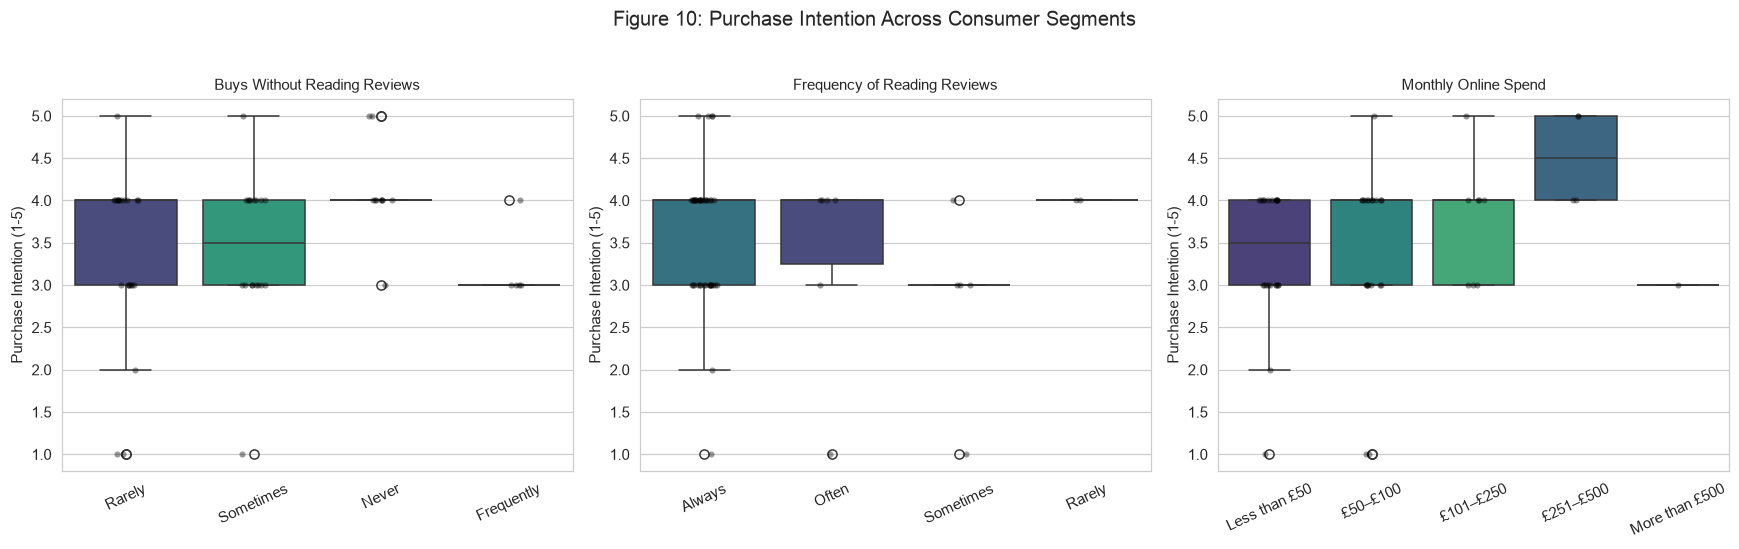

In [46]:
# Visualise purchase intention across the behavioural segments of greatest managerial interest
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_pairs = [('bought_without_reviews', 'Buys Without Reading Reviews'),
              ('review_read_freq', 'Frequency of Reading Reviews'),
              ('monthly_spend', 'Monthly Online Spend')]

for ax, (col, title) in zip(axes, plot_pairs):
    order = [c for c in clean[col].value_counts().index]
    sns.boxplot(x=clean[col], y=clean['PI'], ax=ax, palette='viridis', hue=clean[col],
                legend=False, order=order)
    sns.stripplot(x=clean[col], y=clean['PI'], ax=ax, color='black', alpha=0.4, size=4,
                  order=order)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Purchase Intention (1-5)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Figure 10: Purchase Intention Across Consumer Segments', fontsize=13, y=1.03)
plt.tight_layout()
save_fig('12_group_comparisons')
plt.show()

In [47]:
# Mean purchase intention by segment, for reporting in the findings chapter
segment_means = []
for v in ['bought_without_reviews', 'review_read_freq', 'monthly_spend', 'age', 'gender']:
    g = clean.groupby(v)['PI'].agg(['count', 'mean', 'std', 'median']).round(3)
    g.insert(0, 'Grouping variable', v)
    g = g.reset_index().rename(columns={v: 'Category'})
    segment_means.append(g)

segment_table = pd.concat(segment_means, ignore_index=True)
segment_table.to_csv('table_18_segment_means.csv', index=False)
segment_table

,Category,Grouping variable,count,mean,std,median
0,Frequently,bought_without_reviews,5,3.200,0.447,3.0
1,Never,bought_without_reviews,10,4.100,0.568,4.0
2,Rarely,bought_without_reviews,22,3.364,1.002,4.0
3,Sometimes,bought_without_reviews,18,3.444,0.856,3.5
4,Always,review_read_freq,42,3.595,0.798,4.0
5,Often,review_read_freq,6,3.333,1.211,4.0
6,Rarely,review_read_freq,2,4.000,0.000,4.0
7,Sometimes,review_read_freq,5,2.800,1.095,3.0
8,Less than £50,monthly_spend,22,3.364,0.790,3.5
9,More than £500,monthly_spend,1,3.000,NaN,3.0


---
## 11. Statistical Power Assessment

The achievable statistical power of the regression model is calculated so that any non-significant
result can be interpreted correctly. With a small sample, a non-significant coefficient may reflect
insufficient power rather than the genuine absence of an effect, and this distinction must be drawn
explicitly in the discussion chapter.

In [48]:
from scipy.stats import ncf

n_reg = len(reg_data)
k = 3                                    # number of predictors in the full attitudinal model


def regression_power(n, k, f2, alpha=0.05):
    """Post-hoc power of the overall F-test in multiple regression (Cohen, 1988)."""
    df1, df2 = k, n - k - 1
    lambda_nc = f2 * n                   # non-centrality parameter
    f_crit = stats.f.ppf(1 - alpha, df1, df2)
    return 1 - ncf.cdf(f_crit, df1, df2, lambda_nc)


power_rows = []
for f2, size_label in [(0.02, 'Small'), (0.15, 'Medium'), (0.35, 'Large')]:
    power_rows.append({'Effect size (f-squared)': f2, 'Magnitude': size_label,
                       'n': n_reg, 'Predictors': k,
                       'Achieved power': round(regression_power(n_reg, k, f2), 3)})

power_table = pd.DataFrame(power_rows)
power_table.to_csv('table_19_power_analysis.csv', index=False)

observed_f2 = model3.rsquared / (1 - model3.rsquared)
print(f"Observed effect size of the full model: f-squared = {observed_f2:.4f} "
      f"(R-squared = {model3.rsquared:.4f})")
print(f"Observed power at this effect size: {regression_power(n_reg, k, observed_f2):.3f}")
print("Conventional benchmarks (Cohen, 1988): small = 0.02, medium = 0.15, large = 0.35\n")
print("Table 19: Post-hoc power assessment")
display(power_table)

# Sample size that would have been required to detect a medium effect with power of 0.80
required_n = next(nn for nn in range(20, 1000) if regression_power(nn, k, 0.15) >= 0.80)
print(f"\nSample size required to detect a medium effect (f-squared = 0.15) with power of 0.80, "
      f"three predictors, alpha = .05: n = {required_n}")
print("\nNote: where achieved power falls below the conventional target of 0.80, a non-significant "
      "coefficient should be interpreted as inconclusive rather than as evidence of no effect.")

Observed effect size of the full model: f-squared = 0.1115 (R-squared = 0.1003)
Observed power at this effect size: 0.486
Conventional benchmarks (Cohen, 1988): small = 0.02, medium = 0.15, large = 0.35

Table 19: Post-hoc power assessment


,Effect size (f-squared),Magnitude,n,Predictors,Achieved power
0,0.02,Small,54,3,0.116
1,0.15,Medium,54,3,0.622
2,0.35,Large,54,3,0.953



Sample size required to detect a medium effect (f-squared = 0.15) with power of 0.80, three predictors, alpha = .05: n = 77

Note: where achieved power falls below the conventional target of 0.80, a non-significant coefficient should be interpreted as inconclusive rather than as evidence of no effect.


---
## 12. Summary of Hypothesis Tests

The table below consolidates the evidence relating to each hypothesis and is reproduced directly in
the findings chapter of the dissertation.

In [49]:
hypotheses = [
    ('H1', 'Perceived review quality is positively associated with purchase intention', 'RQ'),
    ('H2', 'Trust in verified-purchase reviews is positively associated with purchase intention',
     'VPT'),
    ('H3', 'Perceived review influence is positively associated with purchase intention', 'RIN'),
]

rows = []
for h, statement, v in hypotheses:
    d = clean[[v, 'PI']].dropna()
    r, p_r = pearsonr(d[v], d['PI'])
    b = model3.params[v]
    p_b = model3.pvalues[v]
    supported = 'Supported' if (p_b < .05 and b > 0) else 'Not supported'
    rows.append({'Hypothesis': h, 'Statement': statement,
                 'Bivariate r': round(r, 3), 'p (r)': round(p_r, 4),
                 'b (Model 3)': round(b, 3), 'p (b)': round(p_b, 4),
                 'Conclusion': supported})

hypothesis_table = pd.DataFrame(rows)
hypothesis_table.to_csv('table_20_hypothesis_summary.csv', index=False)
print("Table 20: Summary of hypothesis tests")
hypothesis_table

Table 20: Summary of hypothesis tests


,Hypothesis,Statement,Bivariate r,p (r),b (Model 3),p (b),Conclusion
0,H1,Perceived review quality is positively associa...,-0.093,0.5043,-0.375,0.0367,Not supported
1,H2,Trust in verified-purchase reviews is positive...,0.130,0.3504,0.324,0.1953,Not supported
2,H3,Perceived review influence is positively assoc...,0.122,0.3810,0.107,0.6480,Not supported


In [50]:
# Consolidated headline results for the abstract and executive summary of the dissertation
print("=" * 80)
print("HEADLINE RESULTS FOR THE DISSERTATION")
print("=" * 80)
print(f"Responses collected                     : {len(df)}")
print(f"Analytical sample after cleaning        : {len(clean)}")
print(f"Cases in the regression models          : {len(reg_data)}")
print()
alpha_col = "Cronbach's alpha"
print("Reliability (Cronbach's alpha):")
for _, r in alpha_table.iterrows():
    print(f"  {r['Construct']:<38}: {r[alpha_col]:.3f} ({r['No. of items']} items)")
print()
print("Composite means (1-5 scale):")
for v in model_vars:
    print(f"  {labels[v]:<38}: M = {clean[v].mean():.3f}, SD = {clean[v].std():.3f}")
print()
print("Full attitudinal model (Model 3):")
print(f"  R-squared                             : {model3.rsquared:.4f}")
print(f"  Adjusted R-squared                    : {model3.rsquared_adj:.4f}")
print(f"  F({int(model3.df_model)}, {int(model3.df_resid)})"
      f"{'':<26}: {model3.fvalue:.3f}, p = {model3.f_pvalue:.4f}")
print()
print("Strongest correlate of purchase intention:")
best = corr_with_dv.reindex(corr_with_dv['Spearman rho'].abs().sort_values(ascending=False).index)
print(best.head(3).to_string(index=False))
print("=" * 80)

HEADLINE RESULTS FOR THE DISSERTATION
Responses collected                     : 55
Analytical sample after cleaning        : 55
Cases in the regression models          : 54

Reliability (Cronbach's alpha):
  Perceived Review Quality              : 0.897 (4 items)
  Trust in Verified-Purchase Reviews    : 0.831 (3 items)
  Perceived Review Influence            : 0.888 (4 items)

Composite means (1-5 scale):
  Perceived Review Quality              : M = 3.829, SD = 1.023
  Trust in Verified Reviews             : M = 3.562, SD = 0.977
  Perceived Review Influence            : M = 3.713, SD = 0.927
  Purchase Intention                    : M = 3.509, SD = 0.879

Full attitudinal model (Model 3):
  R-squared                             : 0.1003
  Adjusted R-squared                    : 0.0463
  F(3, 50)                          : 1.859, p = 0.1486

Strongest correlate of purchase intention:
                Predictor  n  Pearson r  p (Pearson)  Spearman rho  p (Spearman) Significant at .05
 

---
## 13. Reproducibility Statement

All results reported in the dissertation are produced by this notebook. The cleaned dataset
(`cleaned_survey_data.csv`), the variable codebook (`variable_codebook.csv`), every numbered results
table (`table_01` to `table_20`) and every figure used in the report and poster are written to disk
by the cells above, so that a reader can reproduce the full chain of evidence from raw responses to
reported conclusion.

**Repository contents**

* `Purchase_Intention_Analysis.ipynb` — this notebook
* `cleaned_survey_data.csv` — cleaned analytical dataset
* `variable_codebook.csv` — mapping of variable codes to questionnaire wording
* `figures/` — all figures at 300 dpi
* `README.md` — description of the data source and repository contents

In [51]:
# Verify that every output required for the dissertation has been written to disk
import glob
print("Tables produced:")
for f in sorted(glob.glob('table_*.csv')):
    print('  ', f)
print("\nFigures produced:")
for f in sorted(glob.glob('figures/*.png')):
    print('  ', f)
print("\nDatasets produced:")
for f in sorted(glob.glob('*.csv')):
    if not f.startswith('table_'):
        print('  ', f)
print("\nAnalysis complete.")

Tables produced:
   table_01_sample_profile.csv
   table_02_item_descriptives.csv
   table_03_reliability.csv
   table_04_item_analysis.csv
   table_05_composite_descriptives.csv
   table_06_normality.csv
   table_07_pearson_correlations.csv
   table_08_spearman_correlations.csv
   table_09_correlations_with_DV.csv
   table_10_simple_regressions.csv
   table_11_model_comparison.csv
   table_12_final_model_coefficients.csv
   table_13_vif.csv
   table_14_ordinal_logistic.csv
   table_15_sensitivity_analysis.csv
   table_16_bootstrap_ci.csv
   table_17_group_comparisons.csv
   table_18_segment_means.csv
   table_19_power_analysis.csv
   table_20_hypothesis_summary.csv

Figures produced:
   figures/01_missing_data_pattern.png
   figures/02_longstring_screening.png
   figures/03_sample_profile.png
   figures/04_response_distribution.png
   figures/05_composite_distributions.png
   figures/06_correlation_heatmap.png
   figures/07_scatterplots_constructs_vs_PI.png
   figures/08_linearity_res

## 14. Conclusion

### 14.1 Summary of key findings

**The measurement instrument performed well.** All three multi-item constructs achieved good internal consistency — Cronbach's alpha of .897 for perceived review quality, .831 for trust in verified-purchase reviews and .888 for perceived review influence. Every corrected item-total correlation exceeded the .30 threshold, and deleting no item would have improved any scale. The constructs are therefore measured reliably, which means any weak relationship observed downstream cannot be attributed to unreliable measurement.

**Consumers endorse the value of online reviews strongly.** All three constructs sit well above the scale midpoint (M = 3.83, 3.56 and 3.71 on a five-point scale) and all four study variables are negatively skewed. Forty-two of the 55 respondents (76%) report *always* reading reviews before purchasing, and 29 identified customer photographs as the single most important review feature — more than twice the number selecting star ratings (13). By consumers' own account, reviews are central to how they shop online.

**Yet none of these perceptions predicts reported purchase intention.** No construct correlates significantly with the dependent variable (r = .093, .130 and .122; all p > .35). The full attitudinal model explains only 10.0% of the variance in purchase intention and is not statistically significant overall, F(3, 50) = 1.86, p = .149. Hypotheses H1, H2 and H3 are therefore **not supported**.

**The three constructs are highly collinear.** They inter-correlate between r = .67 and r = .83. Consumers who value one attribute of reviews tend to value all of them, which means the constructs — while reliably measured and conceptually distinct — do not behave as independent explanatory levers.

**The apparent negative effect of perceived review quality is a statistical artefact, not a finding.** Perceived review quality shows a near-zero bivariate correlation with purchase intention (r = −.093, p = .504) but a significant negative coefficient once the other constructs are controlled (b = −0.375, p = .037). This is a classic **suppression effect** arising from the high inter-correlation among the predictors. Three independent robustness checks confirm that it must not be interpreted substantively:

| Robustness check | Result for perceived review quality |
|---|---|
| Bootstrapped 95% confidence interval (5,000 resamples) | [−0.761, 0.043] — **includes zero** |
| Ordinal logistic regression | p = .067 — **not significant** |
| Careless-responder sensitivity analysis (n = 52) | p = .076 — **not significant** |

The OLS specification is the only one of four in which this coefficient reaches significance. It would be a serious misinterpretation to conclude that higher perceived review quality reduces purchase intention.

**The only significant correlate of purchase intention is behavioural, not attitudinal.** Respondents who report never or rarely buying a product without first reading reviews report significantly higher review-driven purchase intention (Spearman's rho = .307, p = .023). Monthly online spend approaches conventional significance (rho = .232, p = .089). What consumers habitually *do* tracks their stated intention; what they *say they believe* about reviews does not.

**The regression assumptions were largely satisfied, with one exception.** Linearity held (Rainbow test: F = 1.18, p = .343) and homoscedasticity was satisfied (Breusch-Pagan: LM = 1.62, p = .656). Multicollinearity remained within acceptable bounds (all VIF < 5, though trust in verified reviews was elevated at 4.13, consistent with the suppression effect above). The residuals departed from normality (Shapiro-Wilk W = 0.917, p = .001), which is why the ordinal logistic and bootstrap analyses were conducted — neither assumes normally distributed residuals, and both corroborate the OLS conclusions.

**The null results are inconclusive rather than conclusive.** With n = 54 and three predictors, achieved power is only .62 for a medium effect and .49 at the effect size actually observed — well below the conventional .80 threshold. A sample of approximately 77 would have been required to detect a medium effect reliably. These findings represent an absence of evidence, not evidence of absence.

### 14.2 Answering the research questions

**RQ1 — To what extent do perceived review quality, trust in verified-purchase reviews and perceived review influence predict consumers' reported purchase intention?**

To a negligible and non-significant extent. Together the three constructs account for 10.0% of the variance in purchase intention, and no individual predictor is robustly significant across the OLS, ordinal logistic and bootstrap specifications. The finding illustrates the well-documented gap between generalised evaluative attitudes and stated behavioural intention.

**RQ2 — Which consumer characteristics and review-engagement behaviours are associated with higher review-driven purchase intention?**

Behavioural review reliance is the single significant correlate (rho = .307, p = .023). No demographic or platform-use variable — age, gender, employment status, shopping frequency or preferred platform — produced a significant difference in purchase intention in the non-parametric group comparisons.

### 14.3 Actionable business recommendations

1. **Optimise for review engagement rather than perceived review quality.** Habitual review-reading, not perceived review value, is what tracks purchase intention in this sample. Platforms should make reviews unavoidable in the purchase path — surfacing them above the fold and within the checkout flow — rather than investing solely in review-quality signals.
2. **Prioritise customer photography.** Customer photos were selected as the most important review feature by 29 of 55 respondents, far ahead of every alternative. Incentivising photo submission is inexpensive and directly addresses the attribute consumers value most.
3. **Retain and extend verified-purchase badging.** Trust in verified reviews showed the strongest positive direction of the three constructs, and verified-purchase badging is the least costly credibility signal to implement, making it the natural first candidate for controlled A/B testing. This direction was not statistically significant and should be treated as a hypothesis for testing rather than an established effect.
4. **Treat review accuracy as a returns-cost issue.** Forty-five of the 55 respondents have returned a product because it did not match its reviews. Review-accuracy management therefore belongs in operations and reverse-logistics planning, not marketing alone.
5. **Do not segment customers on review-perception constructs.** Because the three constructs correlate between .67 and .83, treating them as distinct segmentation dimensions would introduce substantial redundancy into any customer model built upon them.

### 14.4 Limitations of the analysis

The analysis rests on a small non-probability convenience sample (n = 55) concentrated among respondents aged 18 to 34 and resident in India, which constrains generalisability. The cross-sectional design precludes causal inference. The dependent variable is a single self-reported item rather than a multi-item scale or observed purchasing behaviour, and all variables were collected through the same instrument at the same point in time, raising the possibility of common method variance. All four study variables depart significantly from normality, which motivated the parallel non-parametric and ordinal analyses reported above. Careless responding was detected in a subset of responses and was addressed through transparent flagging and sensitivity analysis rather than silent deletion. The relatively high proportion of respondents reporting that they always read reviews produces a ceiling effect that restricts variance in a key behavioural variable and reduces the model's capacity to detect relationships.

## Closing statement

This project set out to test whether consumers' perceptions of online product reviews predict their purchase intention. Using a reliably measured instrument, appropriate quantitative methods and a full programme of diagnostic and robustness testing, it finds that they do not — while behavioural review reliance does. The contribution lies less in a confirmed effect than in a carefully evidenced null result, transparently reported, that questions an association the e-commerce literature frequently assumes rather than tests at the individual consumer level.
